<div style="background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
    padding: 50px;
    border-radius: 12px;
    box-shadow: 0 6px 20px rgba(0,0,0,0.25);
    text-align: center;
    color: #f5f5f5;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">    
    <h1 style="margin: 0; font-size: 3em; font-weight: 800; text-transform: uppercase; letter-spacing: 3px;">
        Travaux Pratiques de Machine Learning 2
    </h1>    
    <hr style="width: 120px; border: 2px solid #f1c40f; margin: 25px auto;">
    <p style="font-size: 1.4em; font-style: italic; opacity: 0.95; text-align: center;">
        Étude de cas Olist  Segmentation des Clients
    </p>
</div>


Ce projet sinscrit dans le cadre dune mission de data science pour Olist, une entreprise brésilienne spécialisée dans la vente sur les marketplaces en ligne.

Lobjectif principal est de segmenter les clients afin daider les équipes marketing à mieux comprendre les différents profils dutilisateurs et à adapter leurs stratégies de communication.

Dans ce notebook il sera question de faire une EDA approfondie avant la jointure des différentes bases de données.

## Importation des données

In [1]:
## Bibliothèque nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

try:
    from unidecode import unidecode
except ImportError:
    import subprocess
    subprocess.run(['pip','install','unidecode','-q'])
    from unidecode import unidecode

import plotly.express as px

pd.set_option('display.max_columns', 999)
pd.set_option('display.max_rows', 101)
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Les données sont divisées en plusieurs tables pour faciliter la compréhension et l'organisation. Nous allons importer toutes les bases et les valider avant d'en faire la fusion.

In [ ]:
# Chargement des données avec validation
data_files = {
    'customers': '../data/olist_customers_dataset.csv',
    'geolocation': '../data/olist_geolocation_dataset.csv',
    'order_items': '../data/olist_order_items_dataset.csv',
    'order_payments': '../data/olist_order_payments_dataset.csv',
    'orders': '../data/olist_orders_dataset.csv',
    'products': '../data/olist_products_dataset.csv',
    'sellers': '../data/olist_sellers_dataset.csv',
    'reviews': '../data/olist_order_reviews_dataset.csv',
    'translations': '../data/product_category_name_translation.csv'
}

data = {}
for name, path in data_files.items():
    try:
        # Added engine='python' and on_bad_lines='skip' to handle malformed CSVs
        data[name] = pd.read_csv(path, engine='python', on_bad_lines='skip')
        print(f" {name:15} : {data[name].shape[0]:6} rows et {data[name].shape[1]:2} cols")
    except FileNotFoundError:
        print(f" {name}: Fichier non trouvé - {path}")

# Assigner aux variables globales
customers, geolocation, order_items, order_payments = data['customers'], data['geolocation'], data['order_items'], data['order_payments']
orders, products, sellers, reviews = data['orders'], data['products'], data['sellers'], data['reviews']
translations = data['translations']


 customers       :  99441 rows et  5 cols
 geolocation     : 1000163 rows et  5 cols
 order_items     : 112650 rows et  7 cols
 order_payments  : 103886 rows et  5 cols
 orders          :  99441 rows et  8 cols
 products        :  32951 rows et  9 cols
 sellers         :   3095 rows et  4 cols
 reviews         :  99224 rows et  7 cols
 translations    :     71 rows et  2 cols


Nous disposons de 9 tables avec des lignes allant de 71 à 1000163 et des colonnes de 2 à 9


## Connaissance du jeu de données

### Vue d'ensemble des tables

In [3]:
for table_name, df in data.items():
    print(f"\n Première lignes de la table {table_name.upper()} ")
    display(df.head())


 Première lignes de la table CUSTOMERS 


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



 Première lignes de la table GEOLOCATION 


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



 Première lignes de la table ORDER_ITEMS 


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



 Première lignes de la table REVIEWS 


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



 Première lignes de la table TRANSLATIONS 


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## Analyse des valeurs manquantes

In [4]:
# Analyses de valeurs manquantes

tables = [(name, df) for name, df in data.items()]

for table_name, df in tables:
    missing_count = df.isna().sum().sum()
    missing_pct = (missing_count / (df.shape[0] * df.shape[1]) * 100)
    print(f"\n La table {table_name:15} a {missing_count:6} valeurs manquantes ({missing_pct:.2f}%)")

    # Afficher les colonnes avec des NA
    cols_with_na = df.isna().sum()[df.isna().sum() > 0]
    if len(cols_with_na) > 0:
        for col, count in cols_with_na.items():
            pct = (count / len(df) * 100)
            print(f"   {col:40} : {count:6} ({pct:5.1f}%)")


 La table customers       a      0 valeurs manquantes (0.00%)

 La table geolocation     a      0 valeurs manquantes (0.00%)

 La table order_items     a      0 valeurs manquantes (0.00%)

 La table order_payments  a      0 valeurs manquantes (0.00%)

 La table orders          a   4908 valeurs manquantes (0.62%)
   order_approved_at                        :    160 (  0.2%)
   order_delivered_carrier_date             :   1783 (  1.8%)
   order_delivered_customer_date            :   2965 (  3.0%)

 La table products        a   2448 valeurs manquantes (0.83%)
   product_category_name                    :    610 (  1.9%)
   product_name_lenght                      :    610 (  1.9%)
   product_description_lenght               :    610 (  1.9%)
   product_photos_qty                       :    610 (  1.9%)
   product_weight_g                         :      2 (  0.0%)
   product_length_cm                        :      2 (  0.0%)
   product_height_cm                        :      2 (  0.0%)
  

Les valeurs manquantes sont concentrées sur les tables orders, products et reviews

### Graphe des valeurs manquantes par table

Table orders

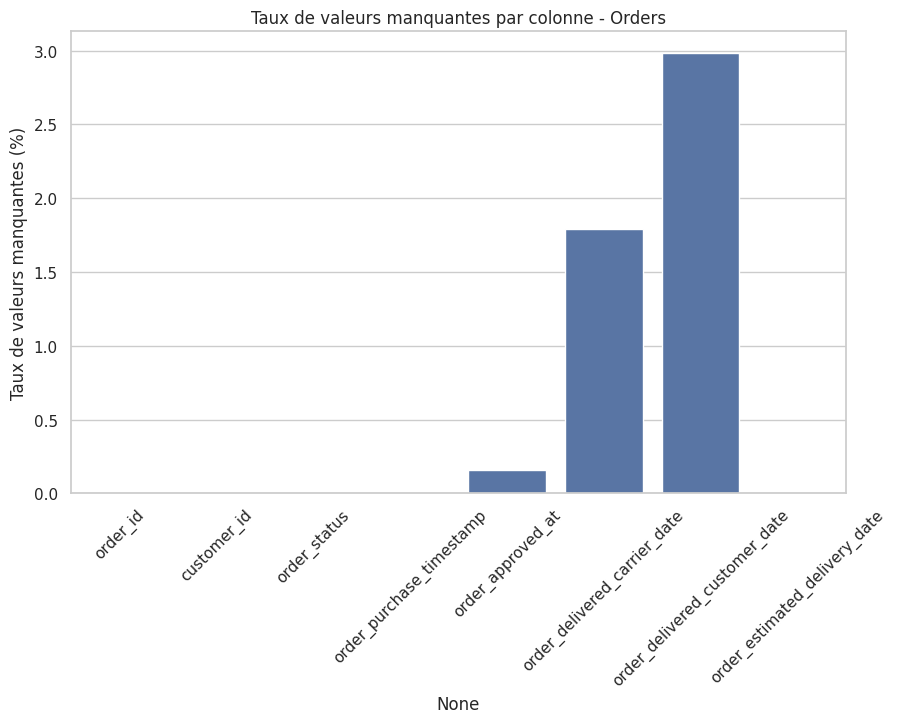

In [5]:
# Graphe du taux de valeurs manquantes par colonne
missing_values = orders.isna().sum() / len(orders) * 100
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=45)
plt.ylabel("Taux de valeurs manquantes (%)")
plt.title("Taux de valeurs manquantes par colonne - Orders")
plt.show()



In [6]:
from pathlib import Path

import missingno as msno

<Axes: >

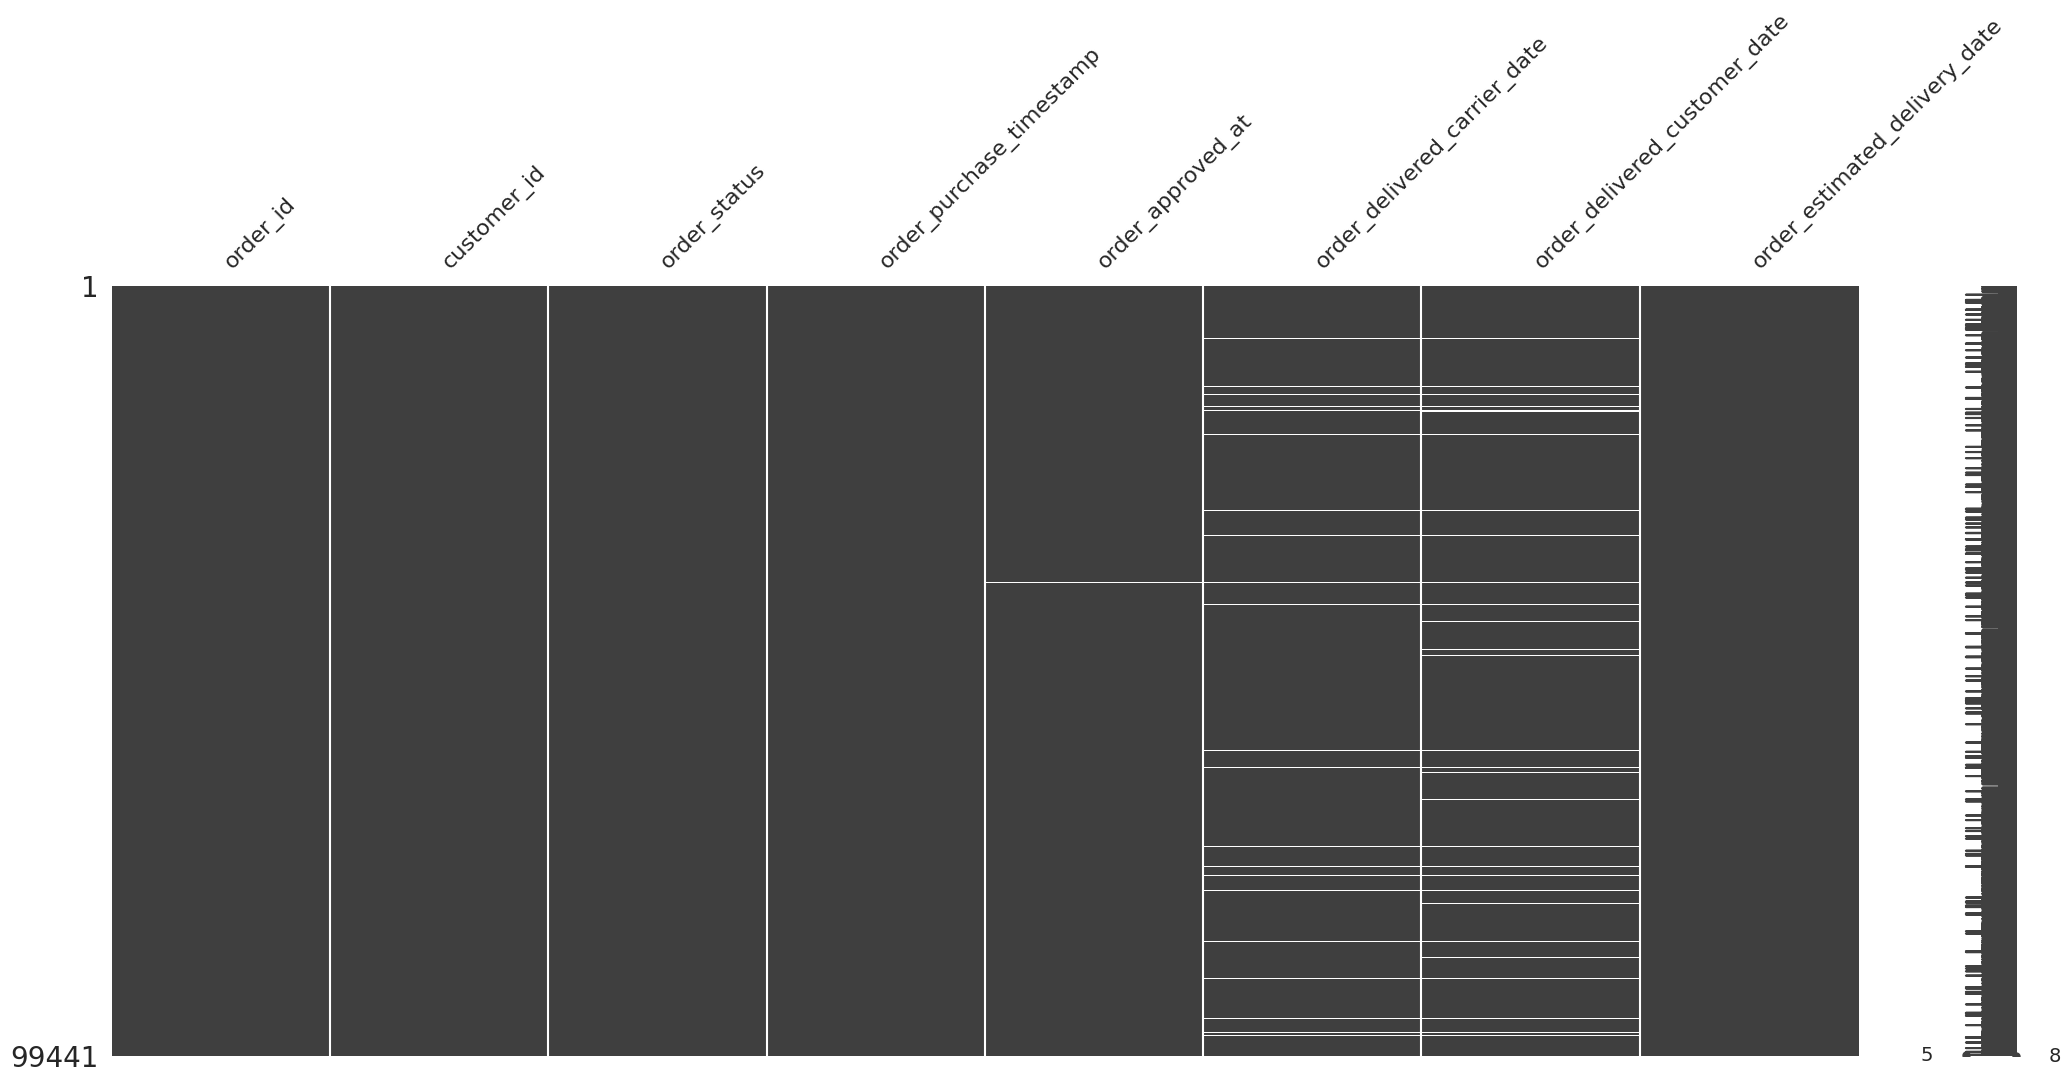

In [7]:

msno.matrix(orders)

Il y a 160 commandes dont le paiement n'a jamais été approuvé. Cela peut arriver si le paiement a été refusé par la banque ou si la commande a été annulée juste après l'achat.
1 783 commandes n'ont pas de date de remise au transporteur. Ce sont probablement des commandes encore en préparation chez le vendeur. Il peut aussi indiquer une annulation ou un problème logistique.
Enfin, 2965 commandes n'ont pas de date de livraison finale. Cela regroupe les commandes en cours de route (expédition lancée mais pas encore arrivée), annulées (en cours de processus), perdues ou ayant rencontré un incident de livraison.

Les valeurs manquantes dans order_approved_at, order_delivered_carrier_date et order_delivered_customer_date traduisent les étapes successives du cycle de vie dune commande : une commande non approuvée ne peut pas être expédiée, et une commande non expédiée ne peut pas être livrée.

#### Table Products

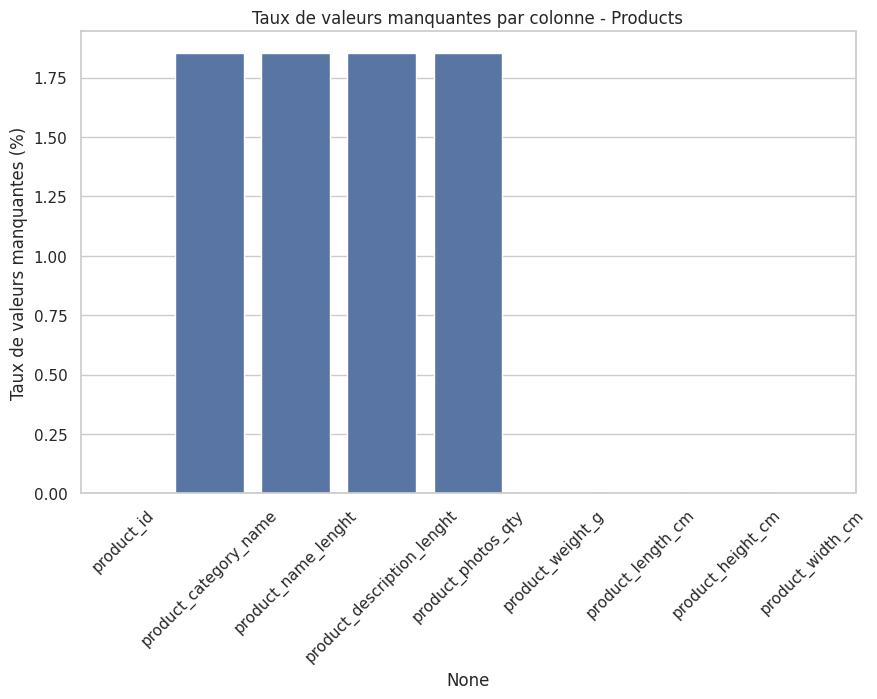

In [8]:
### Taux de valeurs manquantes par colonne
missing_values = products.isna().sum() / len(products) * 100
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=45)
plt.ylabel("Taux de valeurs manquantes (%)")
plt.title("Taux de valeurs manquantes par colonne - Products")
plt.show()

<Axes: >

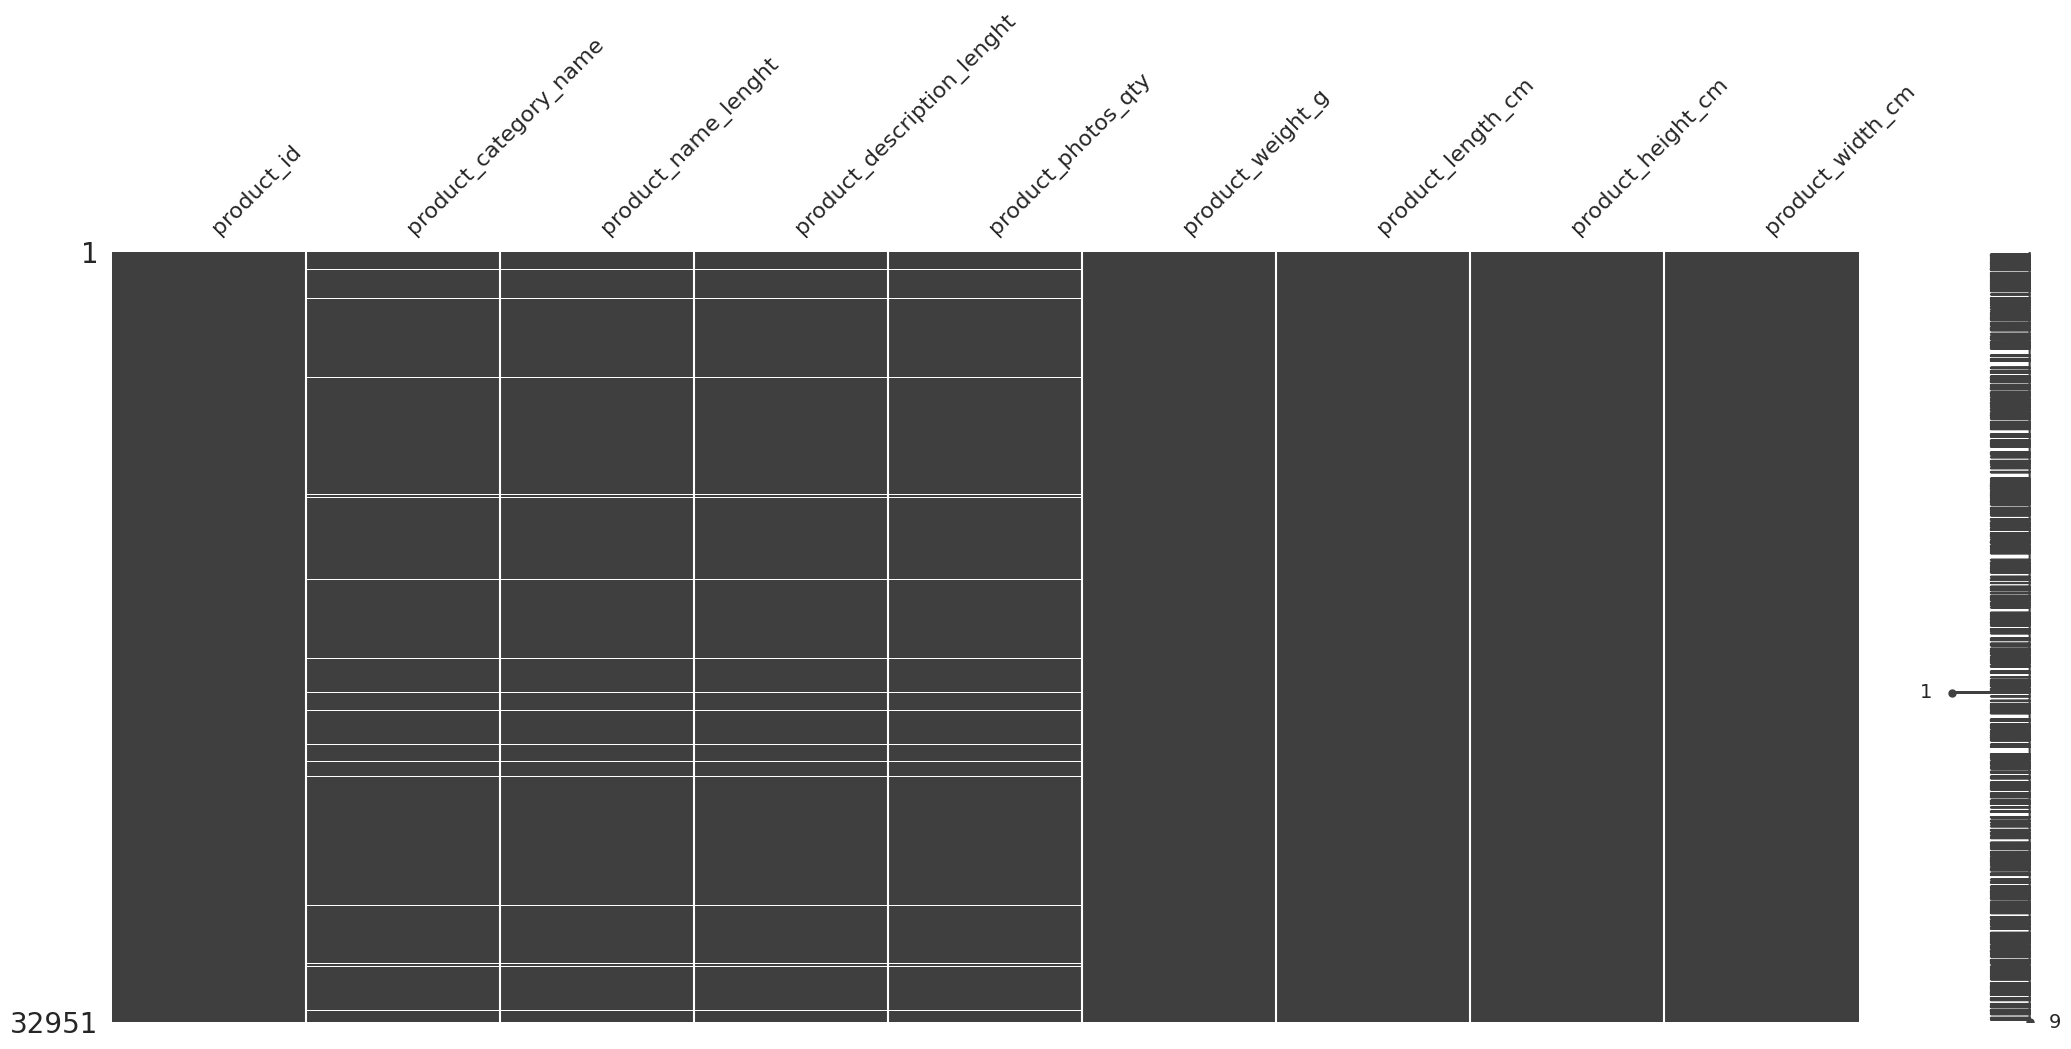

In [9]:

msno.matrix(products)

On distingue deux groupes de NA. Le premier est le bloc des 610, qui correspond à des produits bien enregistrés (ils ont un identifiant), mais dont la fiche marketing est vide : pas de catégorie, pas de description, pas de photos. Cela peut venir de nouveaux produits créés sans détails ou derreurs techniques lors de lintégration des catalogues de vendeurs.

Le second concerne seulement deux produits sans poids ni dimensions. Même si cest rare, cest problématique car Olist ne peut pas calculer automatiquement les frais de port. Ces cas sont probablement liés à une erreur de saisie dun vendeur.

Table reviews

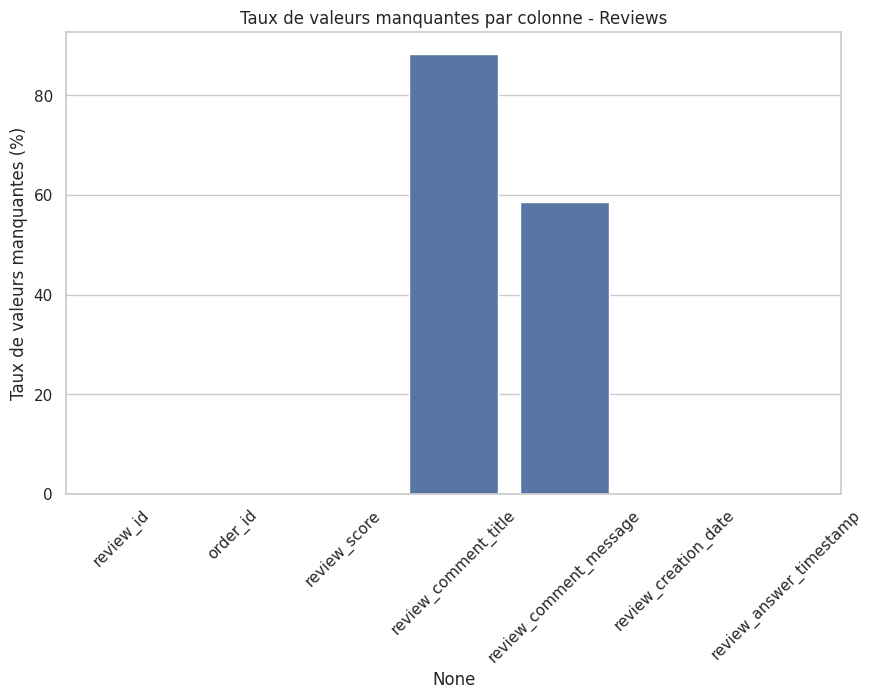

In [10]:
## Taux de valeurs manquantes par colonne
missing_values = reviews.isna().sum() / len(reviews) * 100
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=45)
plt.ylabel("Taux de valeurs manquantes (%)")
plt.title("Taux de valeurs manquantes par colonne - Reviews")
plt.show()


<Axes: >

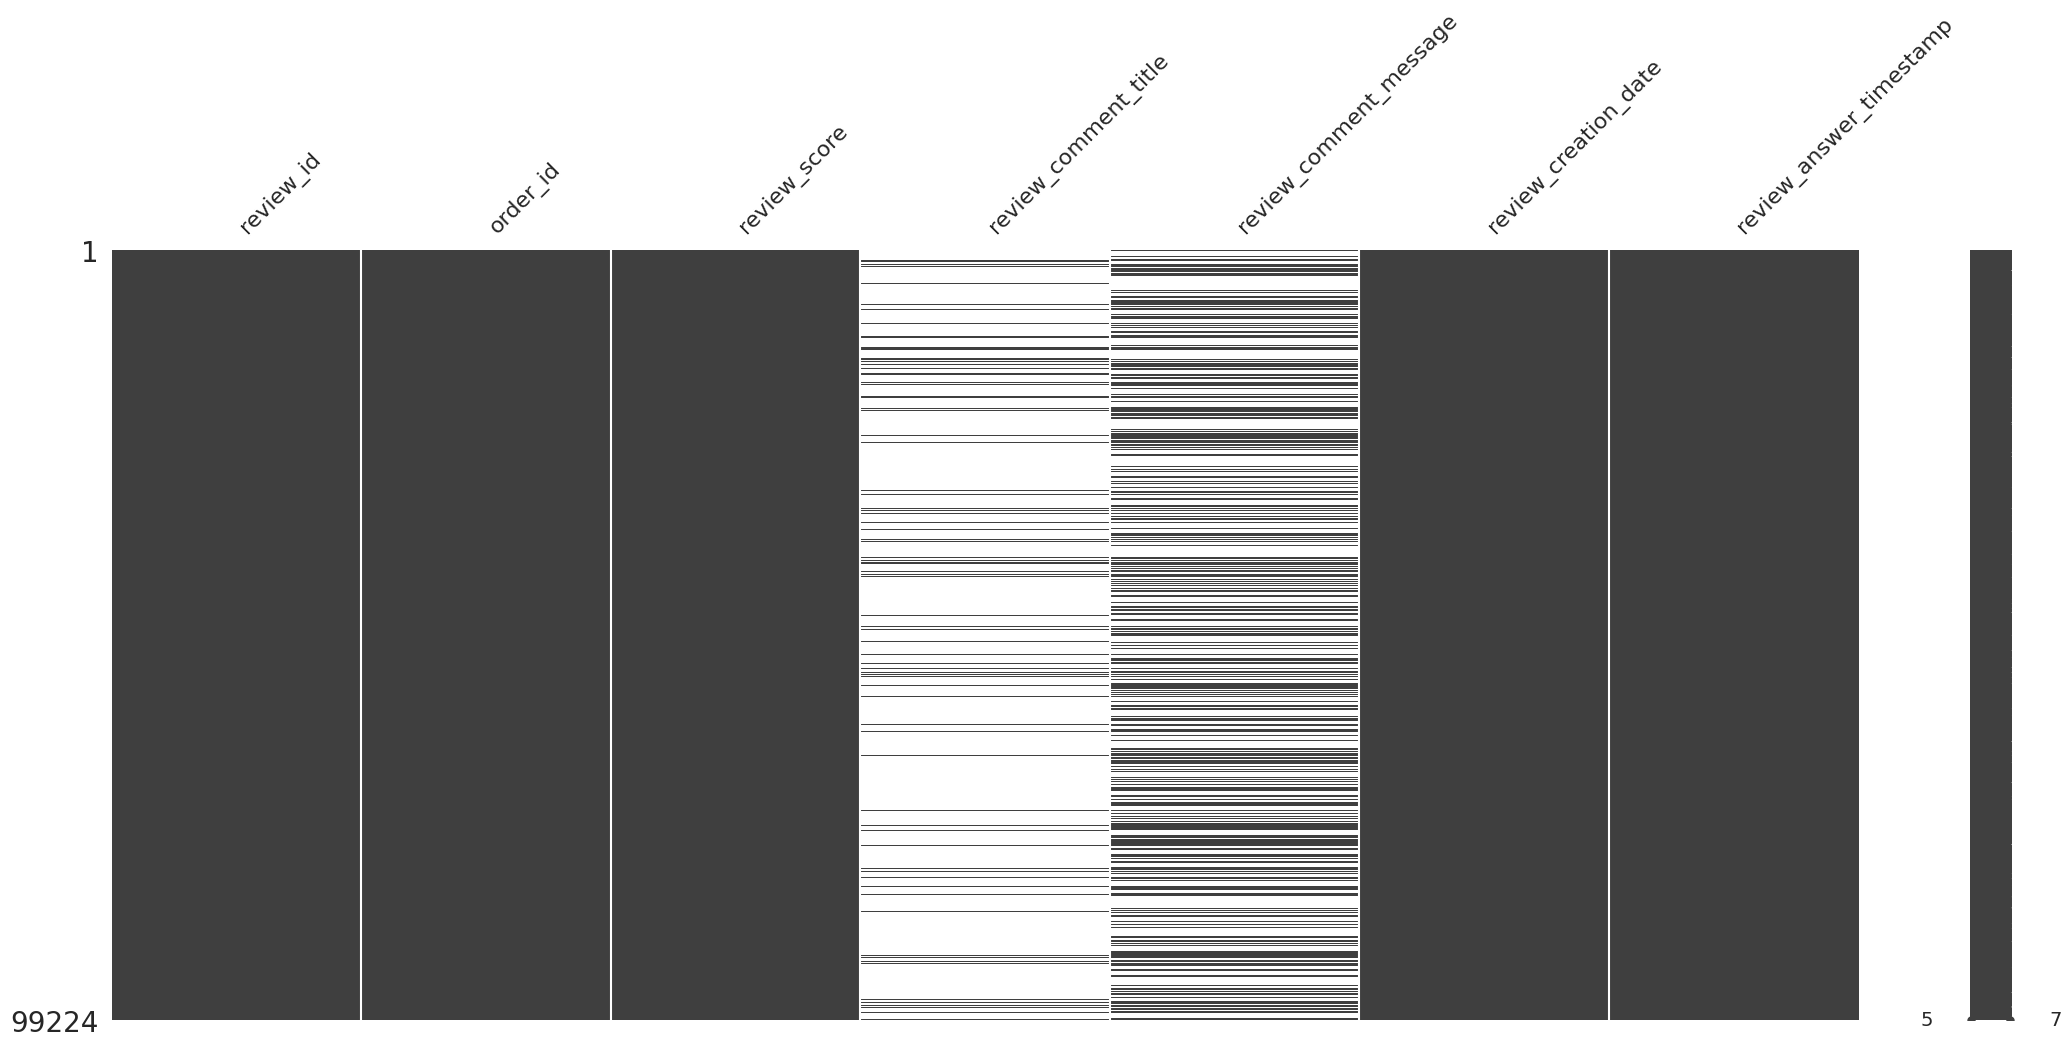

In [11]:

msno.matrix(reviews)

87 656 clients ne donnent pas de titre à leur avis. C'est une étape souvent jugée facultative.

58247 clients laissent une note sans écrire de message.

Pour chaque valeurs manqnante nous retiendrons une méthode de traitement pour les corriger.

## Détection des doublons

In [12]:
# detection des doublons
liste_df = list(data.values())
name_df = list(data.keys())

for i in range(len(liste_df)):
    print(f"Le dataframe {name_df[i]} contient {liste_df[i].duplicated().sum()} doublons.")

Le dataframe customers contient 0 doublons.
Le dataframe geolocation contient 261831 doublons.
Le dataframe order_items contient 0 doublons.
Le dataframe order_payments contient 0 doublons.
Le dataframe orders contient 0 doublons.
Le dataframe products contient 0 doublons.
Le dataframe sellers contient 0 doublons.
Le dataframe reviews contient 0 doublons.
Le dataframe translations contient 0 doublons.


Doublons uniquement dans la table geolocation. Un traitement sera fait pour les traiter.

In [13]:
# Visualisation des données de la table geolocalisation

geolocation[geolocation.duplicated()]


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


Il y a plusieurs lignes identiques. On constate aussi que plusieurs code postal se repètent. Un code postal ne pointe pas vers un point précis (comme une adresse), mais vers une zone (une rue ou un quartier). Les données d'Olist contiennent plusieurs relevés GPS pour une même zone.
Les doublons parfaits seront supprimés et les autres agregés.

## Type de donnée et valeur unique de chaque table

### Analyse de la table customer

In [14]:
customers.info()
customers.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,0
customer_id,99441
customer_unique_id,96096
customer_zip_code_prefix,14994
customer_city,4119
customer_state,27


Le nombre total de commande est de 99441. Comme le nombre de customer_id est supérieur au nombre de customer_unique_id, cela confirme que certains clients ont passé plusieurs commande.
Il y a près de 14994 zones postales différentes représentées dans la base. Aussi Olist couvre plus de 4 000 villes au Brésil. On remarquera souvent que les noms de villes ont des problèmes de saisie (accents, majuscules/minuscules). Ces noms seront traités et harmonisés. 27 states. Il correspond exactement aux 26 États du Brésil + le District Fédéral (Brasília). Cela signifie que tes données couvrent l'intégralité du territoire national sans exception.

In [15]:
# On compte combien de fois chaque ID unique apparaît
counts = customers['customer_unique_id'].value_counts()

# On filtre ceux qui apparaissent plus d'une fois
clients_revenus = counts[counts > 1].count()

print(f"Il y a exactement {clients_revenus} clients qui ont passé plusieurs commandes.")

Il y a exactement 2997 clients qui ont passé plusieurs commandes.


On voit que 2997 clients ont commandé plus d'une fois. On créera une variable qui capte le nombre de commande par clients

In [16]:
# Calculer le nombre de commandes par customer_unique_id
orders_per_customer = customers['customer_unique_id'].value_counts()

# Afficher le top 10 des clients par nombre de commandes
print("Top 10 des clients par nombre de commandes :")
display(orders_per_customer.head(10))

Top 10 des clients par nombre de commandes :


,count
customer_unique_id,
8d50f5eadf50201ccdcedfb9e2ac8455,17
3e43e6105506432c953e165fb2acf44c,9
ca77025e7201e3b30c44b472ff346268,7
1b6c7548a2a1f9037c1fd3ddfed95f33,7
6469f99c1f9dfae7733b25662e7f1782,7
f0e310a6839dce9de1638e0fe5ab282a,6
63cfc61cee11cbe306bff5857d00bfe4,6
12f5d6e1cbf93dafd9dcc19095df0b3d,6
de34b16117594161a6a89c50b289d35a,6


Alors que dans la plupart des commerces en ligne, les meilleurs clients cumulent des dizaines d'achats, on constate ici que le premier client du dataset n'a effectué que 17 commandes sur toute la période. Cette concentration de clients "mono-acheteurs" (environ 97% de la base) signifie que la variable Fréquence sera très peu discriminante pour le modèle de clustering, car la quasi-totalité des individus partagent la même valeur.

### Analyse des codes postal

In [17]:
# On vérifie si un même code postal est rattaché à plusieurs États
check_zip = customers.groupby('customer_zip_code_prefix')['customer_state'].nunique()
print(f"Nombre de codes postaux rattachés à plus d'un État : {(check_zip > 1).sum()}")

Nombre de codes postaux rattachés à plus d'un État : 0


Aucun code postal n'est rattaché à plusieurs Etats

### Analyse des  noms des villes

In [18]:
nb_brut = customers['customer_city'].nunique()
nb_nettoye = customers['customer_city'].str.lower().str.strip().nunique()

# P2-19 : Ajouter la preuve du nombre de doublons
difference_doublons = nb_brut - nb_nettoye

print(f"Nombre de modalités brut : {nb_brut}")
print(f"Nombre de modalités après mise en minuscule + strip : {nb_nettoye}")
print(f"Différence (doublons textuels dus à casse/espaces) : {difference_doublons}")

Nombre de modalités brut : 4119
Nombre de modalités après mise en minuscule + strip : 4119
Différence (doublons textuels dus à casse/espaces) : 0


Aucun doublon textuel detecté dans la table customers

### Table geolocation

In [19]:
geolocation.info()
geolocation.nunique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


,0
geolocation_zip_code_prefix,19015
geolocation_lat,717360
geolocation_lng,717613
geolocation_city,8011
geolocation_state,27


Plus de codes postaux dans geolocalisation que dans customers (19015 contre 14994). La table geolocalisation est une table de référence nationale brésilienne. Il est normal qu'elle contienne des zones où personne n'a encore commandé.

### Table Orders

In [20]:
orders.info()
orders.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,0
order_id,99441
customer_id,99441
order_status,8
order_purchase_timestamp,98875
order_approved_at,90733
order_delivered_carrier_date,81018
order_delivered_customer_date,95664
order_estimated_delivery_date,459


Les dates sont au format object. Nous allons dans la suite faire une conversion en datetime (format approprié).

### Table Order items

In [21]:
order_items.info()
order_items.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


,0
order_id,98666
order_item_id,21
product_id,32951
seller_id,3095
shipping_limit_date,93318
price,5968
freight_value,6999


order_item_id a 21 valeurs uniques. Ce nest pas un identifiant global, mais un compteur interne (1, 2, 3) indiquant le nombre darticles dans une commande.

shipping_limit_date doit être converti en format date pour analyses temporelles.

### Table Order payements

In [22]:
order_payments.info()
order_payments.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


,0
order_id,99440
payment_sequential,29
payment_type,5
payment_installments,24
payment_value,29077


payment_sequential (29) et payment_installments (24). Le Brésil utilise énormément le crédit. Un payment_installments de 24 signifie un paiement en 24 fois. payment_type est important car un client qui paie par "boleto" (virement/cash) a un profil différent d'un client "credit_card".

### Table Products

In [23]:
products.info()
products.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,0
product_id,32951
product_category_name,73
product_name_lenght,66
product_description_lenght,2960
product_photos_qty,19
product_weight_g,2204
product_length_cm,99
product_height_cm,102
product_width_cm,95


## Table translation

In [24]:
translations.info()
translations.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


,0
product_category_name,71
product_category_name_english,71


73 catégories dans products contre 71 dans translation. Il y a un "gap" de 2 catégories. Ces catégories seront recherchées ou remplacées.

73 catégories, c'est beaucoup pour un modèle de ML. Elles pourraient être regoupées dans la suite.

### Table Sellers

In [25]:
sellers.info()
sellers.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


,0
seller_id,3095
seller_zip_code_prefix,2246
seller_city,611
seller_state,23


Cette table donne des informations sur les vendeurs.

### Table Reviews

In [26]:
reviews.info()
reviews.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,0
review_id,98410
order_id,98673
review_score,5
review_comment_title,4527
review_comment_message,36159
review_creation_date,636
review_answer_timestamp,98248


Convertir la date en un format adapté (date)

## Statistiques descriptives

#### Table customers

In [27]:
# Stats descriptives sur la base customers
customers.describe(include='all')


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


Ce tableau confirme la nécessité de l'agrégation : avec 99 441 commandes pour seulement 96 096 clients uniques, environ 3 % de la base est composée de clients fidèles qu'il faut absolument regrouper. L'analyse géographique révèle une concentration massive à São Paulo (SP). Enfin, l'ID avec ses 17 commandes est l'exception statistique qui prouve que le dataset est dominé par des achats uniques, rendant la variable Fréquence très asymétrique.

#### Table order

In [28]:
# stats descriptives sur la base orders
orders.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


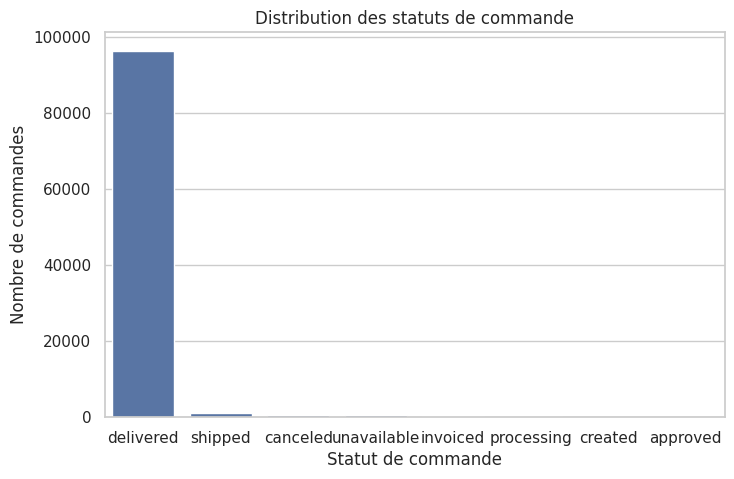

In [29]:
# Graphe de order status
plt.figure(figsize=(8, 5))
sns.countplot(data=orders, x='order_status', order=orders['order_status'].value_counts().index)
plt.title("Distribution des statuts de commande")
plt.xlabel("Statut de commande")
plt.ylabel("Nombre de commandes")
plt.show()

#### Table order items

In [30]:
# stats descriptives sur la base order_items
order_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


Ce tableau révèle que l'activité d'Olist repose sur un volume de 112 650 articles répartis dans 98 666 commandes, ce qui indique un faible taux de multi-achat par panier. La distribution des prix est fortement asymétrique: alors que la moitié des articles coûtent moins de 75 BRL, la moyenne s'élève à 120 BRL à cause d'outliers extrêmes atteignant 6 735 BRL. Cette disparité confirme l'importance de la transformation logarithmique pour un futur calcul du montant total, afin d'éviter que ces produits de luxe ne faussent les centres des clusters. Enfin, les frais de port représentent un coût non négligeable (20 BRL en moyenne), une variable qui pourrait être intéressante à intégrer pour segmenter les clients selon leur sensibilité aux frais de livraison.

Table product

In [31]:
# Stats des sur la table products
products.describe(include='all')


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


Ce tableau montre que le catalogue d'Olist est vaste 32 951 produits et dominé par la catégorie "cama_mesa_banho" (linge de maison). La distribution physique des articles est très hétérogène : si le produit médian est léger (700g) et compact (25cm), certains articles atteignent des extrêmes massifs (40 kg ou plus d'un mètre de long), ce qui explique les fortes variations de frais de port observées précédemment. On note également une certaine uniformité dans le marketing visuel, avec une médiane de une seule photo par produit.

#### Table sellers

In [32]:
# Stats des sur la table sellers
sellers.describe(include='all')


,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


Table orders payement

In [33]:
# Stats des sur la table payement
order_payments.describe(include='all')


,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


L'analyse de ce tableau confirme l'existence de paiements fractionnés, avec 103 886 lignes pour seulement 99 440 commandes uniques, ce qui impose une agrégation par `order_id` pour éviter de dupliquer les revenus lors de la fusion. Le crédit-card est ultra-dominant (74 % des transactions) et l'usage des mensualités est fréquent (moyenne de 2,8, maximum de 24), reflétant les habitudes de consommation brésiliennes. Enfin, l'écart massif entre la moyenne (154) et le maximum (13 664) souligne une forte asymétrie des valeurs, confirmant que sans transformation logarithmique, ces transactions extrêmes écraseraient totalement la segmentation.

Analyse temporelle des commandes

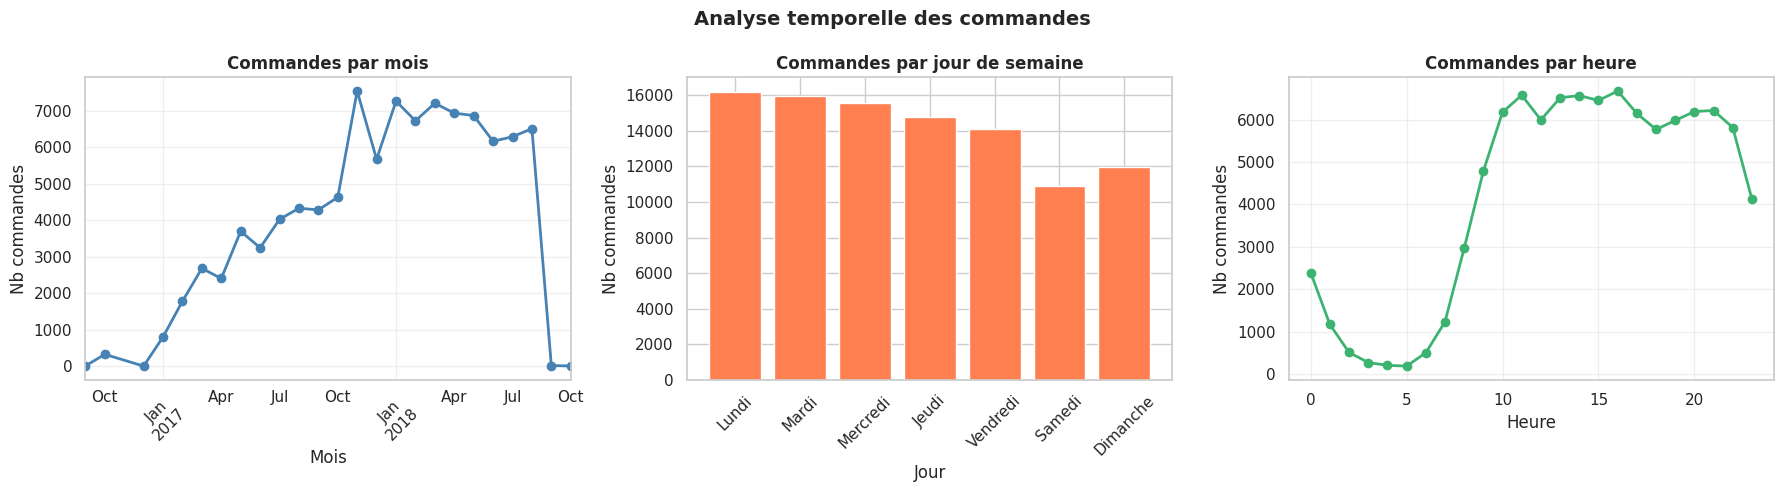

INSIGHT: Pic mensuel en 2017-11
INSIGHT: Heure de pointe : 16h
INSIGHT: Jour le moins actif : Saturday


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Create 1 row and 3 columns for the plots

orders_temp = orders.copy()
orders_temp['purchase_dt'] = pd.to_datetime(orders_temp['order_purchase_timestamp'], errors='coerce')

# Evolution mensuelle
ax = axes[0]
monthly = orders_temp.groupby(orders_temp['purchase_dt'].dt.to_period('M')).size()
monthly.plot(ax=ax, marker='o', color='steelblue', linewidth=2)
ax.set_title('Commandes par mois', fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Nb commandes')
ax.grid(True, alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=45)

# Par jour de la semaine
ax = axes[1]
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_labels = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
orders_temp['day_of_week'] = orders_temp['purchase_dt'].dt.day_name()
day_counts = orders_temp['day_of_week'].value_counts().reindex(day_order)
ax.bar(day_labels, day_counts.values, color='coral', edgecolor='white')
ax.set_title('Commandes par jour de semaine', fontweight='bold')
ax.set_xlabel('Jour')
ax.set_ylabel('Nb commandes')
plt.setp(ax.get_xticklabels(), rotation=45)

# Par heure de la journee
ax = axes[2]
orders_temp['hour'] = orders_temp['purchase_dt'].dt.hour
hour_counts = orders_temp['hour'].value_counts().sort_index()
ax.plot(hour_counts.index, hour_counts.values, 'o-', color='mediumseagreen', linewidth=2)
ax.set_title('Commandes par heure', fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Nb commandes')
ax.grid(True, alpha=0.3)

plt.suptitle('Analyse temporelle des commandes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

top_month  = monthly.idxmax()
peak_hour  = hour_counts.idxmax()
worst_day  = day_counts.idxmin()

print(f'INSIGHT: Pic mensuel en {top_month}')
print(f'INSIGHT: Heure de pointe : {peak_hour}h')
print(f'INSIGHT: Jour le moins actif : {worst_day}')

Le pic de novembre 2017 s'explique par l'impact massif du Black Friday, événement incontournable du e-commerce brésilien qui génère un volume de commandes exceptionnel. L'heure de pointe à 16h indique un comportement d'achat principalement "de bureau" ou en milieu d'après-midi, plutôt qu'en soirée. Enfin, le fait que le samedi soit le jour le moins actif souligne une utilisation utilitaire de la plateforme en semaine, les clients délaissant les achats en ligne pendant leurs loisirs du week-end.

Text(0.5, 1.0, 'Matrice de rétention mensuelle')

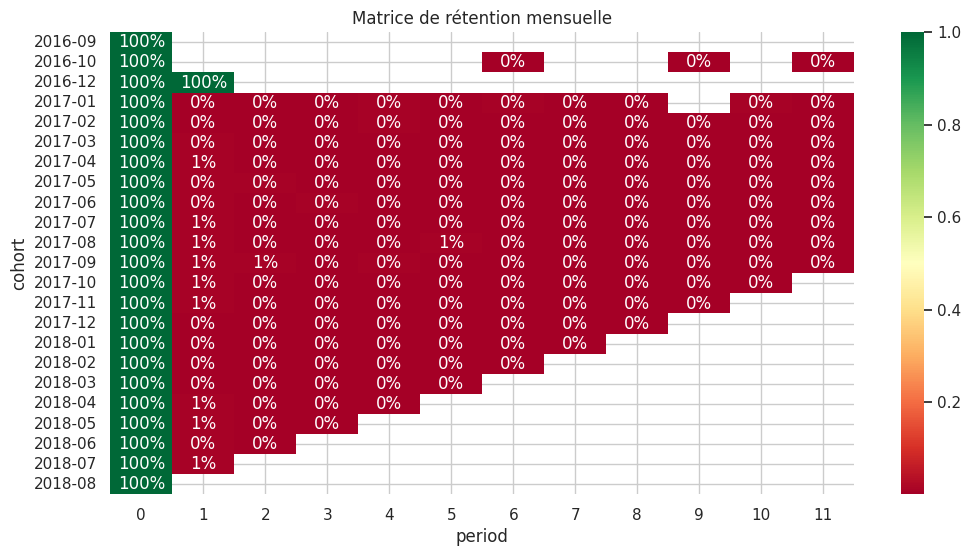

In [35]:
# Cohorte mensuelle basique
orders_coh = orders[orders['order_status']=='delivered'].copy()
orders_coh['purchase_month'] = pd.to_datetime(orders_coh['order_purchase_timestamp']).dt.to_period('M')
orders_coh = orders_coh.merge(customers[['customer_id','customer_unique_id']], on='customer_id')

cohort = orders_coh.groupby(['customer_unique_id','purchase_month']).size().reset_index()
cohort['cohort'] = cohort.groupby('customer_unique_id')['purchase_month'].transform('min')
cohort['period'] = (cohort['purchase_month'] - cohort['cohort']).apply(lambda x: x.n)

retention = cohort.groupby(['cohort','period'])['customer_unique_id'].nunique().unstack()
retention_rate = retention.divide(retention[0], axis=0)

sns.heatmap(retention_rate.iloc[:, :12], annot=True, fmt='.0%', cmap='RdYlGn')
plt.title('Matrice de rétention mensuelle')


Analyse geographique des clients


In [36]:
clients_per_state = customers['customer_state'].value_counts().reset_index()
clients_per_state.columns = ['State', 'Number of Clients']
print("Number of Clients per State:")
display(clients_per_state)

Number of Clients per State:


,State,Number of Clients
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


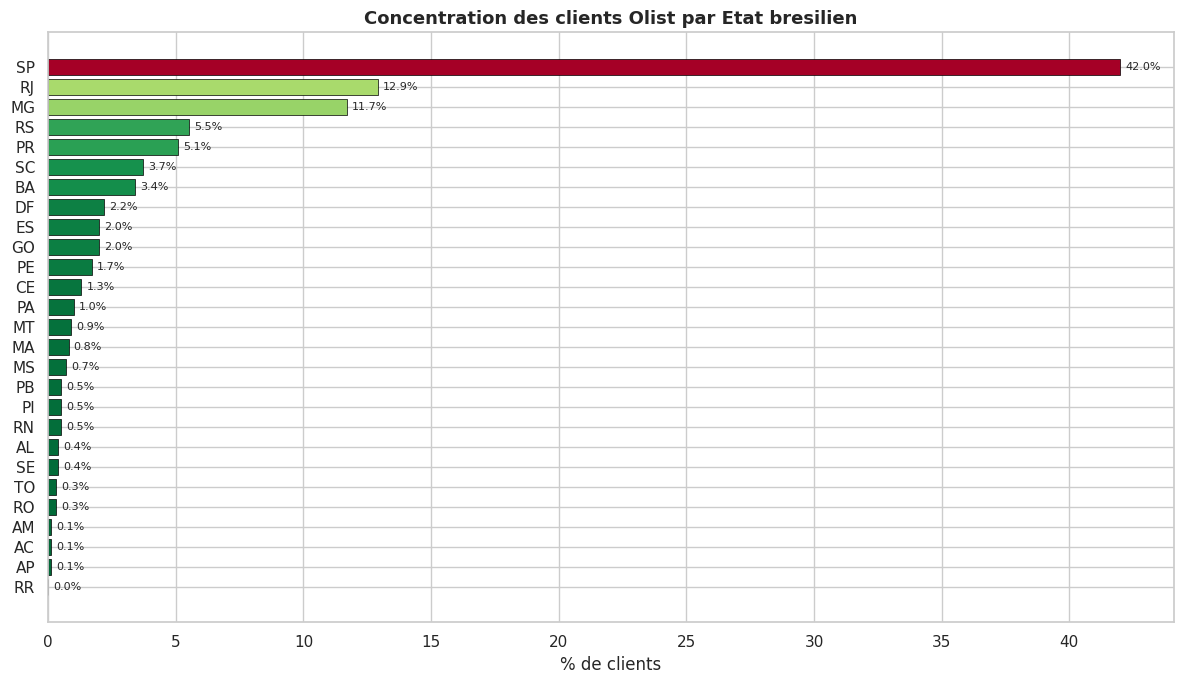

In [37]:
# Carte choropleth des clients par etat
state_clients = customers['customer_state'].value_counts().reset_index()
state_clients.columns = ['state', 'count']
state_clients['percentage'] = (state_clients['count'] / state_clients['count'].sum() * 100).round(1)

# Graphique barres en fallback (fonctionne sans GeoJSON externe)
plt.figure(figsize=(12, 7))
colors = plt.cm.RdYlGn_r(state_clients['percentage'] / state_clients['percentage'].max())
bars = plt.barh(state_clients['state'], state_clients['percentage'], color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(state_clients['percentage']):
    plt.text(v + 0.2, i, f'{v}%', va='center', fontsize=8)
plt.title('Concentration des clients Olist par Etat bresilien', fontweight='bold', fontsize=13)
plt.xlabel('% de clients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Cette répartition géographique met en évidence une **hégémonie massive de l'État de São Paulo (SP)**, qui concentre à lui seul près de $42\,\%$ de ta clientèle totale. En y ajoutant Rio de Janeiro (RJ) et Minas Gerais (MG), le Sud-Est brésilien regroupe environ **deux tiers de l'activité**, confirmant que le marché d'Olist est fortement polarisé autour des grands pôles économiques. Cette disparité crée une "longue traîne" où les Etats du Nord (comme RR avec 46 clients) pèsent très peu. Ainsi la localisation est un levier logistique majeur : les délais et frais de port seront structurellement plus bas pour la majorité des clients, créant un biais géographique naturel.

### Analyse des délais de livraison

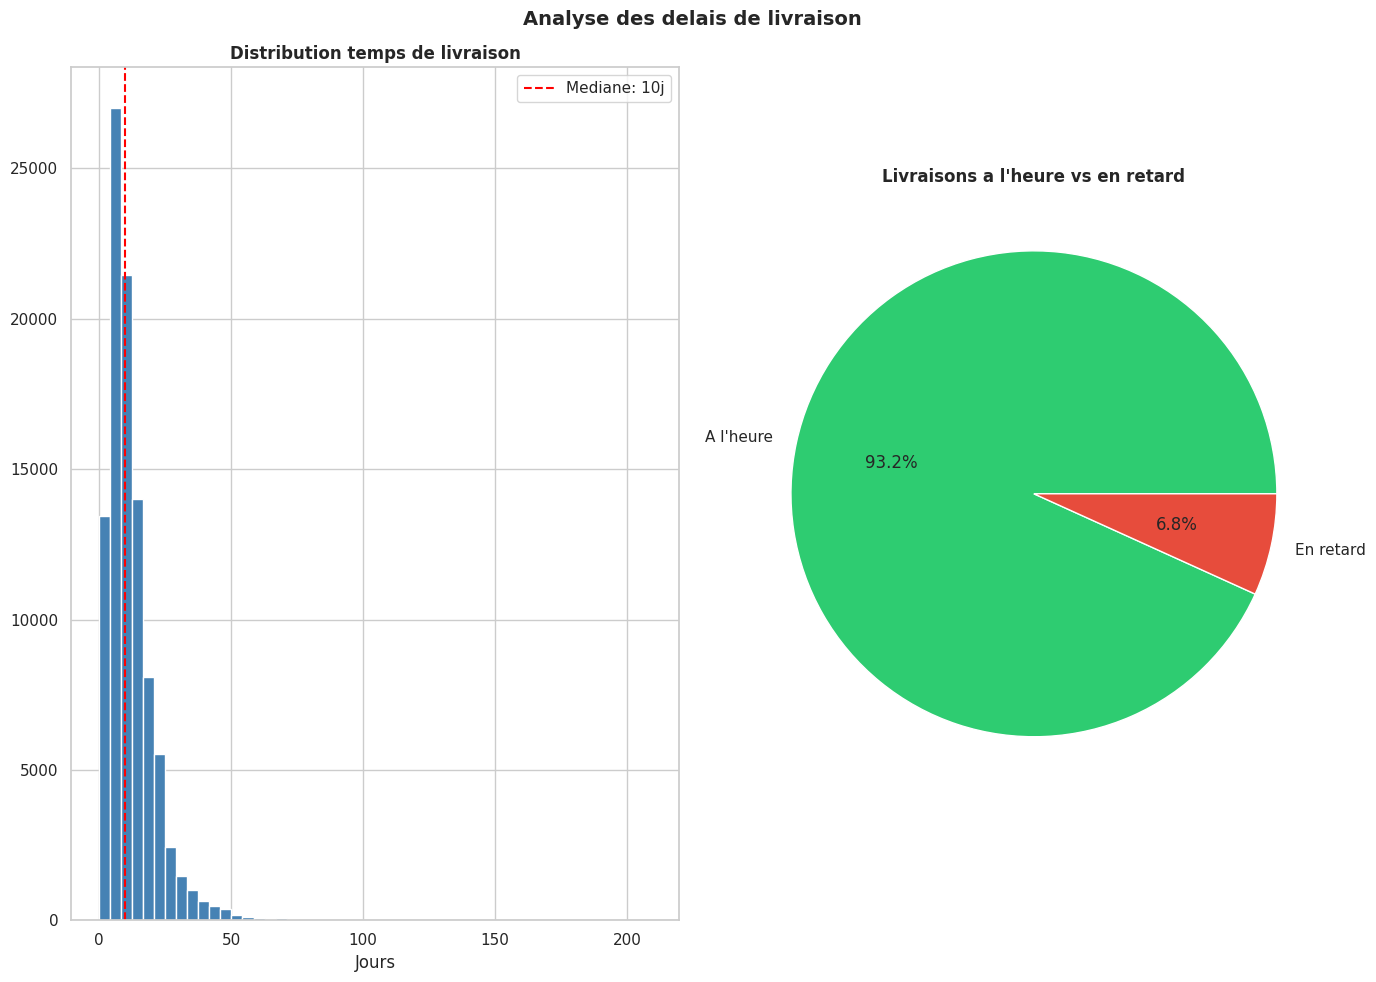

In [38]:
orders_del = orders.copy()
for col in ['order_delivered_customer_date','order_estimated_delivery_date','order_purchase_timestamp']:
    orders_del[col] = pd.to_datetime(orders_del[col], errors='coerce')

orders_del['delivery_time'] = (orders_del['order_delivered_customer_date'] - orders_del['order_purchase_timestamp']).dt.days
orders_del['delivery_delay'] = (orders_del['order_delivered_customer_date'] - orders_del['order_estimated_delivery_date']).dt.days
delivered = orders_del[orders_del['order_delivered_customer_date'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

ax = axes[0]
delivered['delivery_time'].dropna().hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
med = delivered['delivery_time'].median()
ax.axvline(med, color='red', linestyle='--', label=f'Mediane: {med:.0f}j')
ax.set_title('Distribution temps de livraison', fontweight='bold')
ax.set_xlabel('Jours')
ax.legend()

ax = axes[1]
on_time = (delivered['delivery_delay'] <= 0).sum()
delayed  = (delivered['delivery_delay'] > 0).sum()
ax.pie([on_time, delayed], labels=['A l\'heure','En retard'],
       autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
ax.set_title(f'Livraisons a l\'heure vs en retard', fontweight='bold')


plt.suptitle('Analyse des delais de livraison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

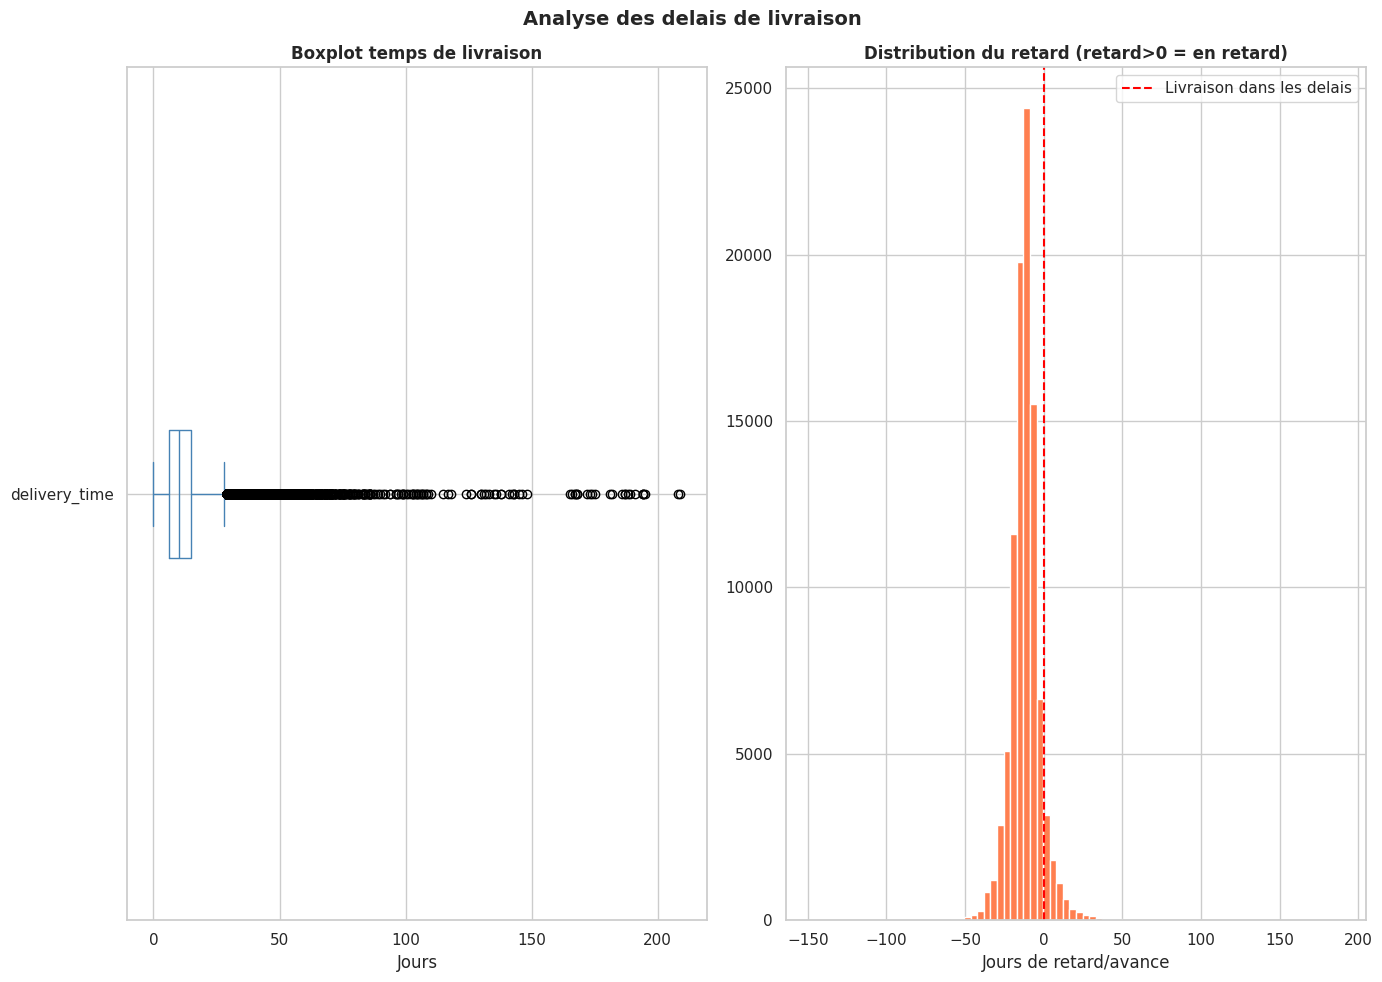

In [39]:
orders_del = orders.copy()
for col in ['order_delivered_customer_date','order_estimated_delivery_date','order_purchase_timestamp']:
    orders_del[col] = pd.to_datetime(orders_del[col], errors='coerce')

orders_del['delivery_time'] = (orders_del['order_delivered_customer_date'] - orders_del['order_purchase_timestamp']).dt.days
orders_del['delivery_delay'] = (orders_del['order_delivered_customer_date'] - orders_del['order_estimated_delivery_date']).dt.days
delivered = orders_del[orders_del['order_delivered_customer_date'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 10))


ax = axes[0]
delivered['delivery_time'].dropna().plot(kind='box', ax=ax, vert=False, color='steelblue')
ax.set_title('Boxplot temps de livraison', fontweight='bold')
ax.set_xlabel('Jours')

ax = axes[1]
delivered['delivery_delay'].dropna().hist(bins=80, ax=ax, color='coral', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='Livraison dans les delais')
ax.set_title('Distribution du retard (retard>0 = en retard)', fontweight='bold')
ax.set_xlabel('Jours de retard/avance')
ax.legend()

plt.suptitle('Analyse des delais de livraison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

L’analyse des délais de livraison met en évidence une distribution asymétrique caractérisée par une médiane d’environ 10 jours et la présence de valeurs extrêmes. La majorité des livraisons est effectuée dans les délais ou en avance (plus de 93%), ce qui traduit une bonne performance logistique. Toutefois, une faible proportion de retards et des délais exceptionnellement longs suggèrent l’existence de dysfonctionnements ponctuels pouvant impacter l’expérience client.

#### Taux de retard par Etat

In [40]:
# Merge delivered orders with customer data to get state information
delivered_with_state = delivered.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

# Calculate total orders and delayed orders per state
state_delay = delivered_with_state.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    delayed_orders=('delivery_delay', lambda x: (x > 0).sum())
).reset_index()

# Calculate the delay rate
state_delay['delay_rate'] = (state_delay['delayed_orders'] / state_delay['total_orders'] * 100).round(2)

# Sort by delay rate for better visualization
state_delay = state_delay.sort_values(by='delay_rate', ascending=False)

print("Delivery Delay per State:")
display(state_delay.head())


Delivery Delay per State:


,customer_state,total_orders,delayed_orders,delay_rate
1,AL,397,85,21.41
9,MA,717,125,17.43
24,SE,335,51,15.22
16,PI,476,66,13.87
5,CE,1279,176,13.76


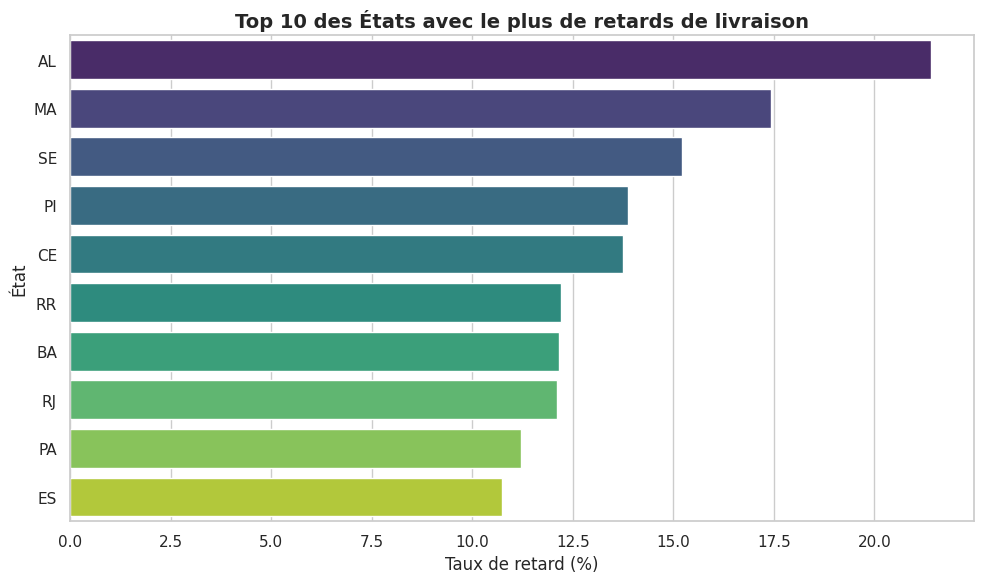

In [41]:
# Graphique du Top 10 des etats avec plus de retard
fig, ax = plt.subplots(figsize=(10, 6))

top_10_delayed_states = state_delay.head(10)

sns.barplot(x='delay_rate', y='customer_state', data=top_10_delayed_states, palette='viridis', ax=ax)
ax.set_title('Top 10 des États avec le plus de retards de livraison', fontweight='bold', fontsize=14)
ax.set_xlabel('Taux de retard (%)', fontsize=12)
ax.set_ylabel('État', fontsize=12)
plt.tight_layout()
plt.show()

Ce graphique révèle une fracture logistique nette entre le cœur économique du Brésil et ses régions périphériques : les taux de retard les plus critiques (dépassant les 20 %) se concentrent dans le Nord et le Nord-Est (**AL**, **MA**, **SE**), prouvant que l'éloignement des centres de distribution de São Paulo dégrade mécaniquement l'expérience client. La présence notable de **Rio de Janeiro (RJ)** dans ce top 10, malgré sa proximité géographique, souligne que des facteurs urbains ou structurels locaux impactent aussi la fiabilité des livraisons.

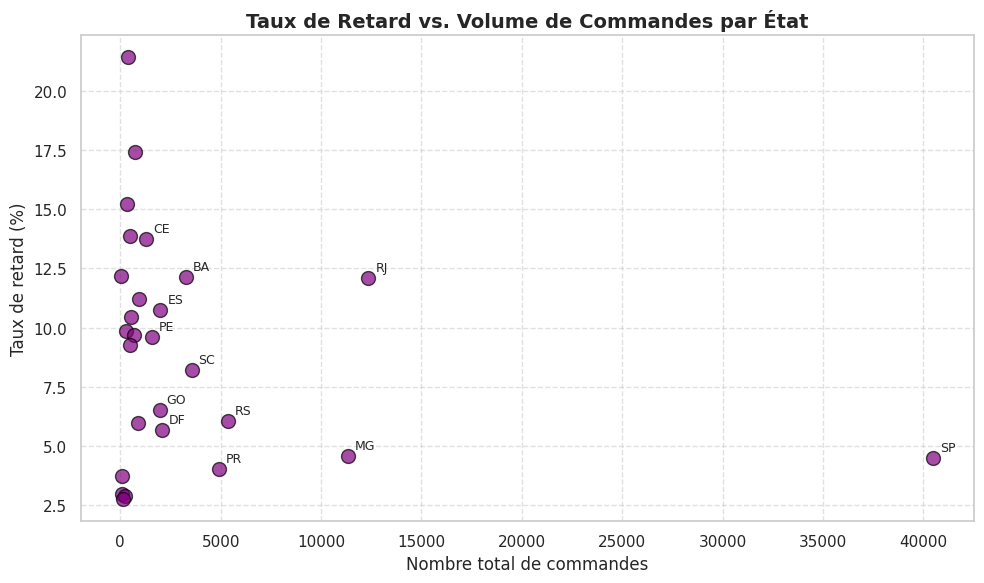

In [42]:
# Graphique de comparaison entre les taux de retard et le nombre de reatrd

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(state_delay['total_orders'], state_delay['delay_rate'], s=100, alpha=0.7, color='purple', edgecolor='black')
ax.set_title('Taux de Retard vs. Volume de Commandes par État', fontweight='bold', fontsize=14)
ax.set_xlabel('Nombre total de commandes', fontsize=12)
ax.set_ylabel('Taux de retard (%)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# Annoter les points avec les noms des États si le volume est significatif (par exemple, > 1000 commandes)
for idx, row in state_delay.iterrows():
    if row['total_orders'] > 1000:
        ax.annotate(row['customer_state'], (row['total_orders'], row['delay_rate']),
                    fontsize=9, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

Ce graphique en nuage de points croise la performance (taux de retard) avec l'importance business (volume de commandes), permettant de prioriser les zones d'intervention :

* **Le pôle d'efficacité (Bas à droite) :** **SP** (São Paulo) et **MG** (Minas Gerais) affichent les volumes les plus élevés avec les taux de retard les plus bas (environ 5 %). Ce sont les moteurs du business où la logistique est parfaitement maîtrisée.
* **L'anomalie critique (Milieu haut) :** **RJ** (Rio de Janeiro) se détache dangereusement. C'est le seul État avec un volume massif (plus de 10 000 commandes) qui subit un taux de retard élevé (12 %). Contrairement aux petits États du Nord, l'impact financier des retards à Rio est colossal pour Olist.
* **La zone de risque (Haut à gauche) :** On y retrouve les États comme **CE**, **BA** ou ceux non étiquetés culminant à 21 % de retard. Si leur volume individuel est faible, leur accumulation crée une mauvaise image de marque nationale.
* **La performance locale (Bas gauche) :** **PR** (Paraná), où se trouve le siège à Curitiba, maintient un excellent score (4 % de retard) malgré un volume intermédiaire, confirmant l'avantage de la proximité géographique.

#### Analyse des paiements

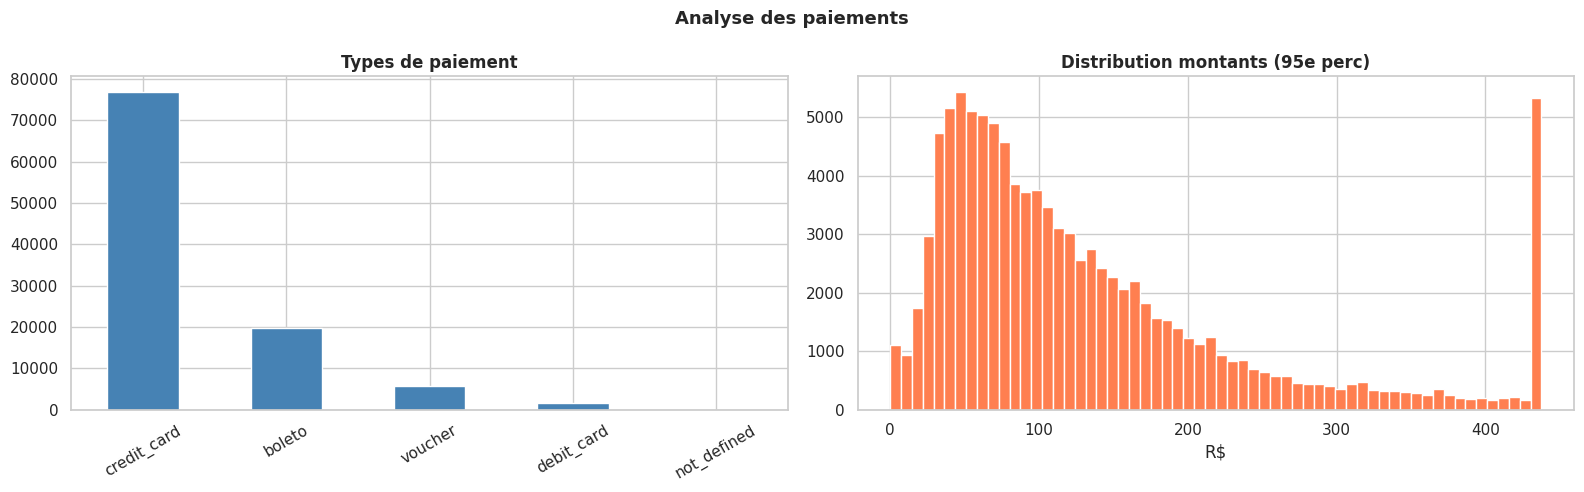

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Types de paiement
ax = axes[0]
order_payments['payment_type'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Types de paiement', fontweight='bold')
ax.set_xlabel('')
plt.setp(ax.get_xticklabels(), rotation=30)

# Distribution montants
ax = axes[1]
order_payments['payment_value'].clip(upper=order_payments['payment_value'].quantile(0.95)).hist(
    bins=60, ax=ax, color='coral', edgecolor='white')
ax.set_title('Distribution montants (95e perc)', fontweight='bold')
ax.set_xlabel('R$')

plt.suptitle('Analyse des paiements', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

L'analyse des paiements montre une hégémonie de la **carte de crédit**, confirmant l'importance du crédit à la consommation au Brésil, complétée par l'usage du **Boleto** pour une part non négligeable des transactions. Cette préférence pour le paiement par carte est un levier de conversion majeur, mais elle introduit aussi une complexité dans l'analyse financière du fait des paiements échelonnés.

Sur le plan des montants, la distribution est très concentrée sur de petits paniers, avec un cœur de marché situé entre **50 R\$ et 150 R\$**. La présence d'une accumulation de valeurs élevées au-delà de 450 R\$ (le 95e percentile) confirme que le catalogue attire une majorité d'acheteurs de produits courants, tandis qu'une minorité "Premium" se détache nettement.

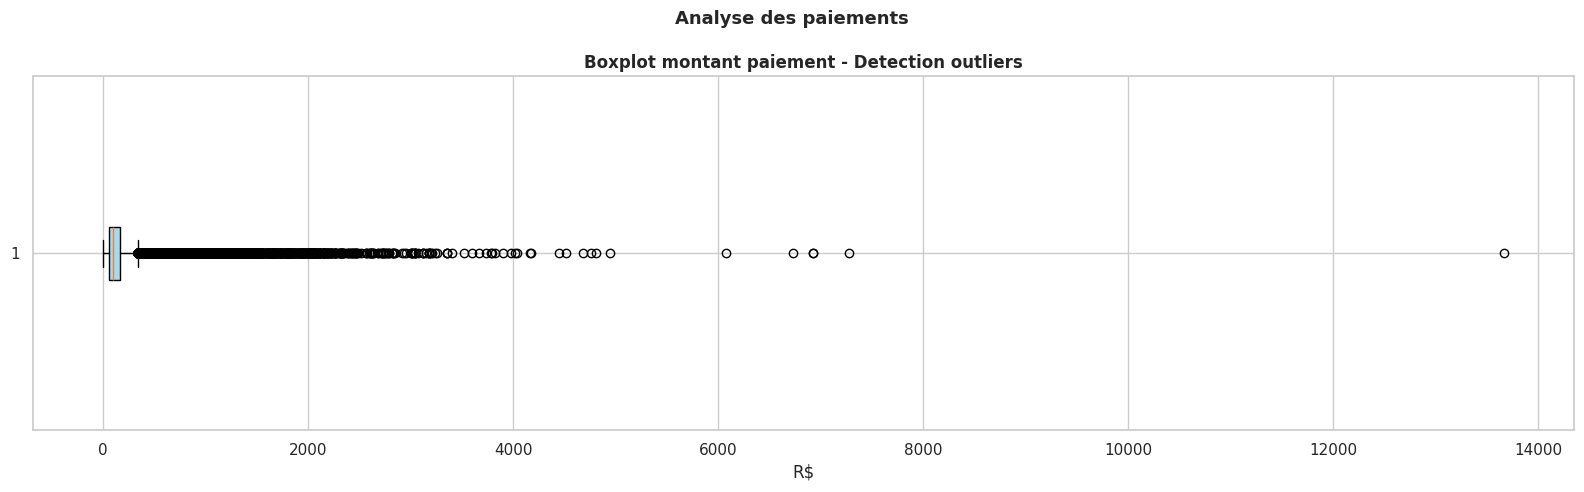

In [44]:
# Boxplot outliers
fig, axes = plt.subplots(1, 1, figsize=(16, 5))

axes.boxplot(order_payments['payment_value'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
axes.set_title('Boxplot montant paiement - Detection outliers', fontweight='bold')
axes.set_xlabel('R$')

plt.suptitle('Analyse des paiements', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Ce boxplot du montant des paiements illustre graphiquement le phénomène d'asymétrie extrême que nous avions identifié dans les statistiques descriptives.

L'immense majorité des transactions est compressée sur la gauche du graphique, avec une boîte (représentant les 50 % centraux des données) située très près de zéro. Cette zone dense correspond aux achats du quotidien, généralement inférieurs à 500 R\$. À l'inverse, la ligne de points s'étirant vers la droite montre une quantité massive d'outliers qui s'étendent jusqu'à plus de 13 000 R\$.


Pour le modèle de machine learning, ce graphique confirme qu'une simple normalisation ne suffira pas. Sans une transformation logarithmique préalable, ces quelques points extrêmes à droite agiraient comme des aimants sur l'algorithme K-Means, créant un cluster pour un seul individu "ultra-riche" et regroupant tout le reste de la clientèle dans un seul bloc indifférencié.

Analyse de la satisfaction

[None, None, None, None, None]

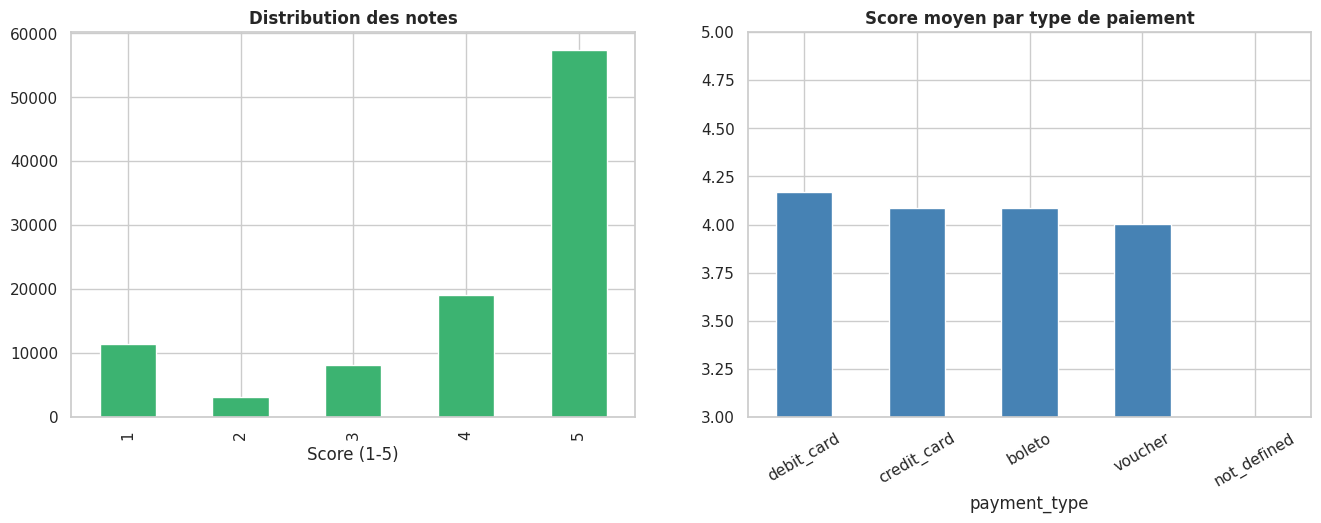

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution des scores
ax = axes[0]
reviews['review_score'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Distribution des notes', fontweight='bold')
ax.set_xlabel('Score (1-5)')

# Satisfaction par type de paiement
ax = axes[1]
pay_rev = order_payments.merge(reviews[['order_id','review_score']], on='order_id', how='left')
pay_rev.groupby('payment_type')['review_score'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Score moyen par type de paiement', fontweight='bold')
ax.set_ylim(3, 5)
plt.setp(ax.get_xticklabels(), rotation=30)

La distribution des notes montre une satisfaction client très polarisée : une immense majorité de scores parfaits (5/5) coexiste avec un volume significatif de notes minimales (1/5), tandis que les notes intermédiaires restent marginales. Cette structure "en U" suggère une expérience utilisateur sans nuance, où l'insatisfaction est souvent radicale, probablement déclenchée par les incidents logistiques identifiés précédemment plutôt que par une insatisfaction progressive vis-à-vis des produits.

L'analyse par mode de paiement révèle une légère corrélation avec la satisfaction, où les utilisateurs de cartes de débit affichent les meilleurs scores moyens, contrairement aux bénéficiaires de bons d'achat.

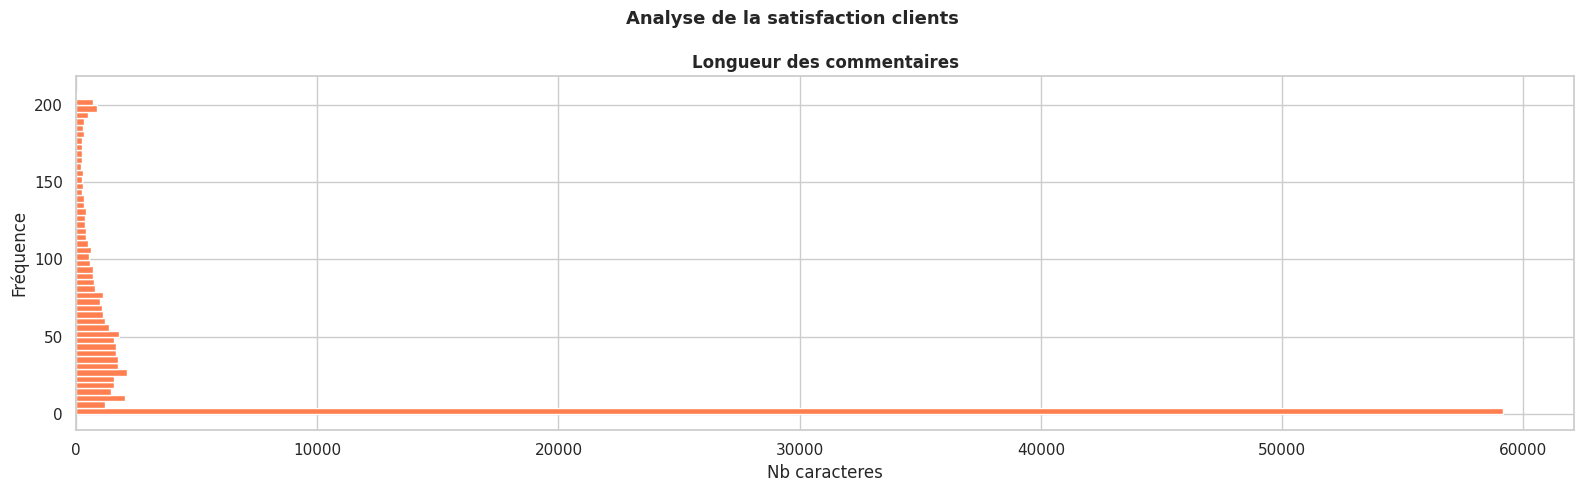

In [46]:
# Longueur des commentaires
fig, axes = plt.subplots(1, 1, figsize=(16, 5))
reviews['review_length'] = reviews['review_comment_message'].fillna('').apply(len)
reviews['review_length'].clip(upper=500).hist(bins=50, ax=axes, color='coral', edgecolor='white', orientation='horizontal')
axes.set_title('Longueur des commentaires', fontweight='bold')
axes.set_xlabel('Nb caracteres')
axes.set_ylabel('Fréquence') # Adding y-label for clarity in horizontal histogram

plt.suptitle('Analyse de la satisfaction clients', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

L'histogramme révèle qu'une immense majorité de clients laisse des commentaires extrêmement courts ou vides, comme l'indique la barre massive à la base du graphique (proche de 0 caractère). On observe cependant une distribution décroissante de commentaires allant jusqu'à 200 caractères, ce qui montre que seule une petite fraction de la clientèle prend le temps de rédiger un avis détaillé.

Dans le cadre de ton projet Olist, cette donnée est un indicateur précieux de l'engagement ou de la frustration. Généralement, les commentaires très longs sont soit le signe d'une satisfaction exceptionnelle, soit, plus souvent, le reflet d'un mécontentement profond lié à des problèmes de livraison

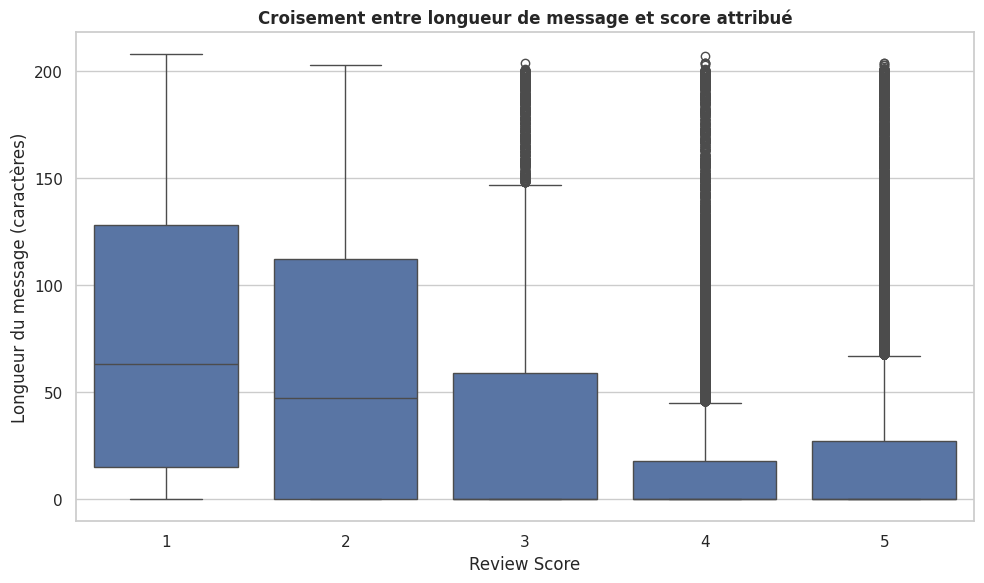

In [47]:
reviews['review_length'] = reviews['review_comment_message'].fillna('').apply(len)
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_score', y=reviews['review_length'].clip(upper=500), data=reviews)
plt.title('Croisement entre longueur de message et score attribué', fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Longueur du message (caractères)')
plt.tight_layout()
plt.show()

On observe une relation inversement proportionnelle entre la note et la longueur du message : les clients qui attribuent un score de 1 écrivent les commentaires les plus longs (médiane plus élevée et boîte plus étirée). À l'inverse, les clients attribuant un 5 sont les plus concis. Les "outliers" (points noirs) sont présents partout, mais la masse des messages détaillés se concentre clairement sur les notes de 1 à 3. Cela prouve que le silence est un signe de satisfaction chez Olist : quand tout va bien, le client ne dit rien ou reste bref. En revanche, le besoin de s'exprimer et de détailler l'expérience est un moteur puissant de l'insatisfaction

Distribution du nombre de vendeurs uniques par client:


,num_unique_sellers
count,95420.000000
mean,1.038000
std,0.217025
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,10.000000


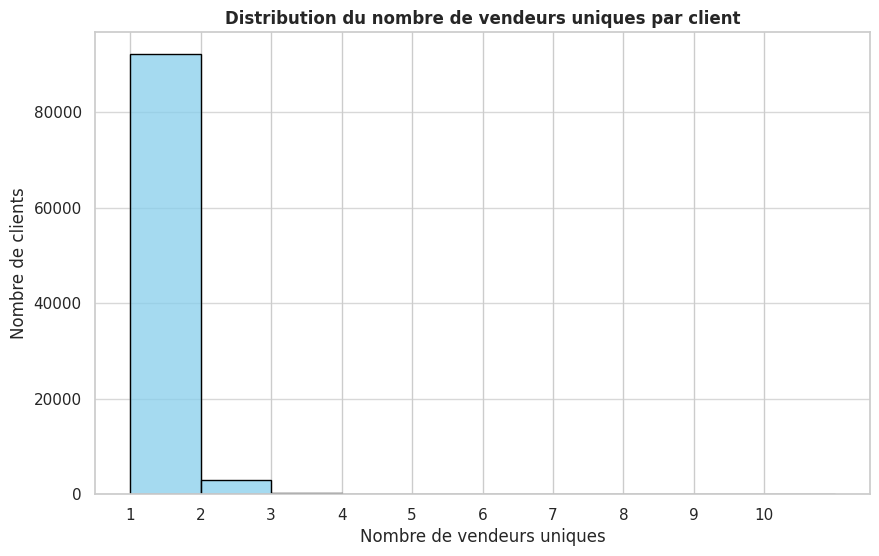


Corrélation entre le nombre de vendeurs uniques et le score de satisfaction moyen: -0.054


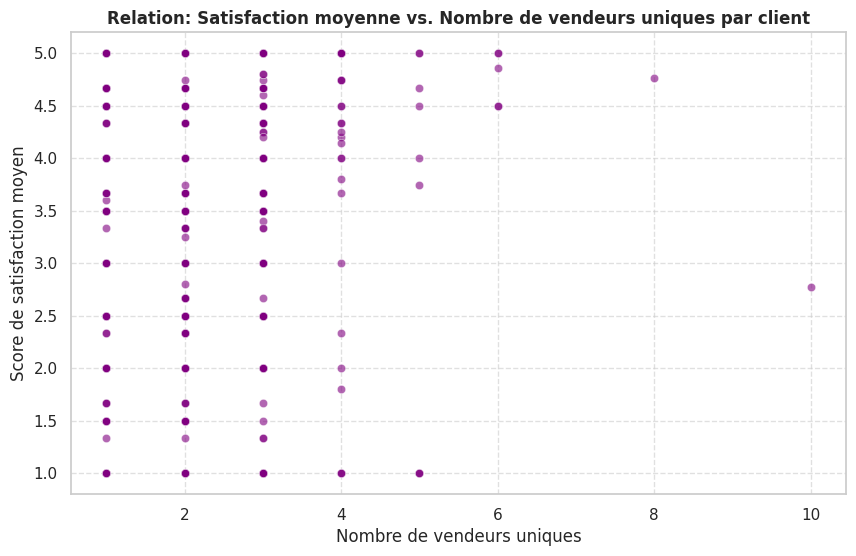

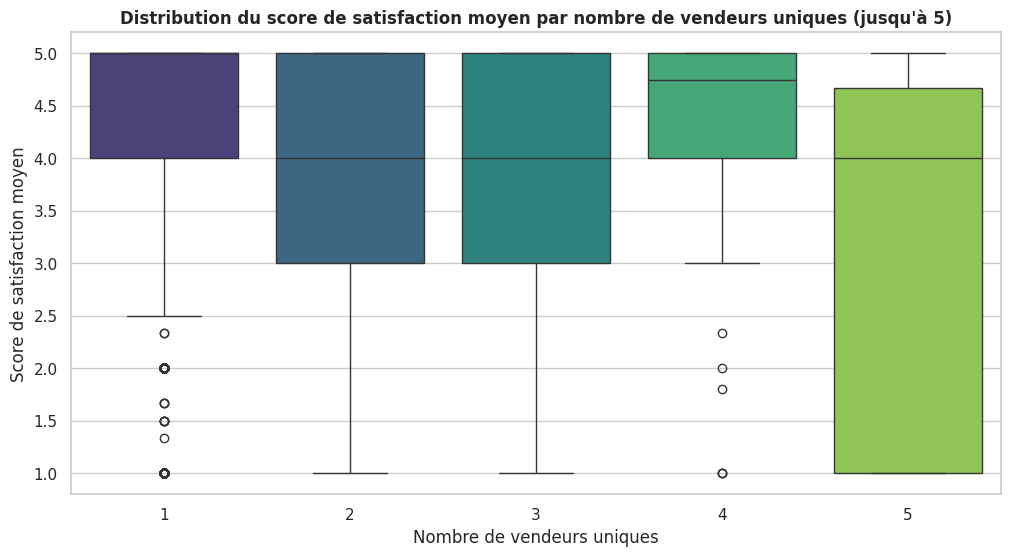


Note: 7 clients ont acheté auprès de plus de 5 vendeurs uniques. Un boxplot avec plus de catégories serait trop dense.


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the number of unique sellers per customer
# We need to ensure we count unique (customer_unique_id, seller_id) pairs across all orders.
# Link customers -> orders -> order_items
customer_order_link = pd.merge(
    customers[['customer_id', 'customer_unique_id']],
    orders[['order_id', 'customer_id']],
    on='customer_id',
    how='inner'
)

customer_seller_interactions = pd.merge(
    customer_order_link[['customer_unique_id', 'order_id']],
    order_items[['order_id', 'seller_id']],
    on='order_id',
    how='inner'
).drop_duplicates(subset=['customer_unique_id', 'seller_id']) # Drop duplicates to count unique (customer, seller) pairs

num_unique_sellers_per_customer = customer_seller_interactions.groupby('customer_unique_id')['seller_id'].nunique().reset_index()
num_unique_sellers_per_customer.rename(columns={'seller_id': 'num_unique_sellers'}, inplace=True)

print("Distribution du nombre de vendeurs uniques par client:")
display(num_unique_sellers_per_customer['num_unique_sellers'].describe())

# Plotting the distribution of unique sellers per customer
plt.figure(figsize=(10, 6))
sns.histplot(num_unique_sellers_per_customer['num_unique_sellers'], bins=range(1, num_unique_sellers_per_customer['num_unique_sellers'].max() + 2), kde=False, color='skyblue', edgecolor='black')
plt.title('Distribution du nombre de vendeurs uniques par client', fontweight='bold')
plt.xlabel('Nombre de vendeurs uniques')
plt.ylabel('Nombre de clients')
plt.xticks(range(1, min(num_unique_sellers_per_customer['num_unique_sellers'].max() + 1, 15))) # Limit x-ticks for readability
plt.grid(axis='y', alpha=0.75)
plt.show()

# 2. Correlate with customer satisfaction
# Calculate average review score per customer
# Filter out NA review scores per order before averaging per customer to avoid issues.
# Link customers -> orders -> reviews
customer_reviews_raw = pd.merge(
    customer_order_link[['customer_unique_id', 'order_id']], # Reuse customer_order_link
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

# Aggregate to get average review score per customer_unique_id
avg_review_score_per_customer = customer_reviews_raw.dropna(subset=['review_score']).groupby('customer_unique_id')['review_score'].mean().reset_index()
avg_review_score_per_customer.rename(columns={'review_score': 'avg_customer_review_score'}, inplace=True)

# Merge the number of unique sellers with average review score per customer
customer_seller_satisfaction = pd.merge(
    num_unique_sellers_per_customer,
    avg_review_score_per_customer,
    on='customer_unique_id',
    how='inner' # Use inner join to only consider customers with both seller info and reviews
)

print(f"\nCorrélation entre le nombre de vendeurs uniques et le score de satisfaction moyen: {customer_seller_satisfaction['num_unique_sellers'].corr(customer_seller_satisfaction['avg_customer_review_score']):.3f}")

# Scatter plot for correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(x='num_unique_sellers', y='avg_customer_review_score', data=customer_seller_satisfaction, alpha=0.6, color='purple')
plt.title('Relation: Satisfaction moyenne vs. Nombre de vendeurs uniques par client', fontweight='bold')
plt.xlabel('Nombre de vendeurs uniques')
plt.ylabel('Score de satisfaction moyen')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Boxplot of average satisfaction score by number of unique sellers (for a reasonable range)
plt.figure(figsize=(12, 6))
# Filter for num_unique_sellers to make the boxplot readable, e.g., <= 5
sns.boxplot(x='num_unique_sellers', y='avg_customer_review_score',
            data=customer_seller_satisfaction[customer_seller_satisfaction['num_unique_sellers'] <= 5],
            palette='viridis')
plt.title('Distribution du score de satisfaction moyen par nombre de vendeurs uniques (jusqu\'à 5)', fontweight='bold')
plt.xlabel('Nombre de vendeurs uniques')
plt.ylabel('Score de satisfaction moyen')
plt.show()

# Add a check if there are many customers with more than 5 unique sellers
if (customer_seller_satisfaction['num_unique_sellers'] > 5).any():
    print(f"\nNote: {len(customer_seller_satisfaction[customer_seller_satisfaction['num_unique_sellers'] > 5])} clients ont acheté auprès de plus de 5 vendeurs uniques. Un boxplot avec plus de catégories serait trop dense.")

#### Analyse des catégories de produits

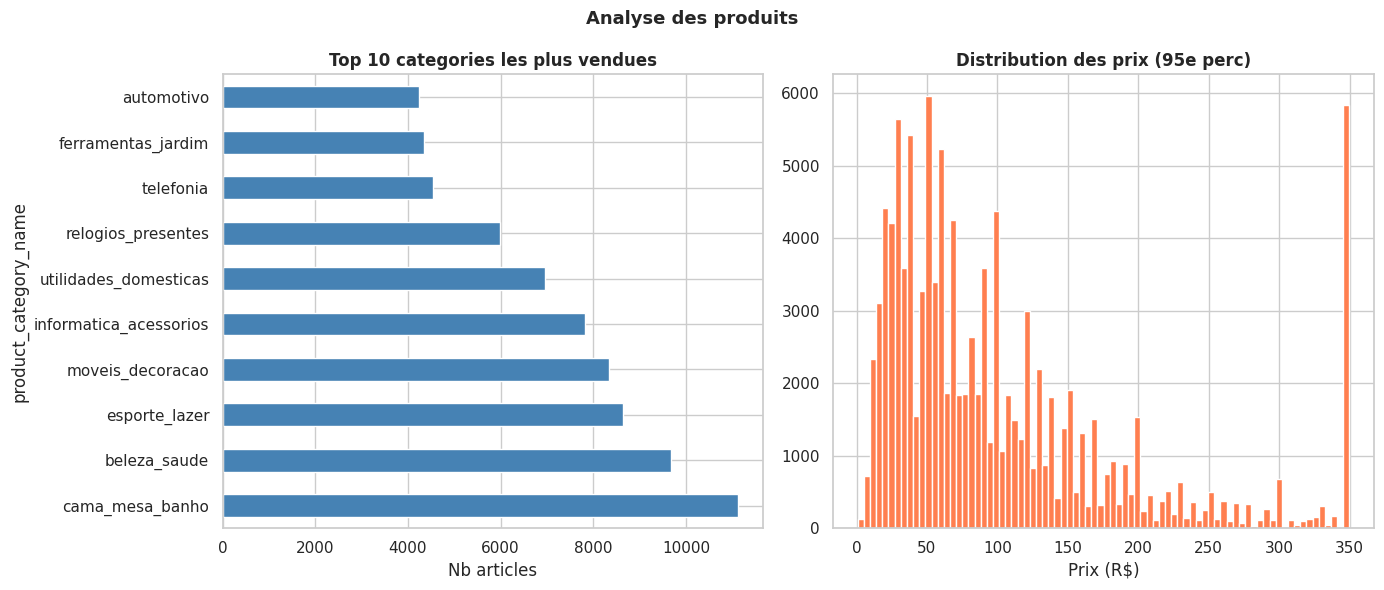

In [49]:
products_orders = products.merge(order_items, on='product_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
products_orders['product_category_name'].value_counts().head(10).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 categories les plus vendues', fontweight='bold')
ax.set_xlabel('Nb articles')

ax = axes[1]
order_items['price'].clip(upper=order_items['price'].quantile(0.95)).hist(
    bins=80, ax=ax, color='coral', edgecolor='white')
ax.set_title('Distribution des prix (95e perc)', fontweight='bold')
ax.set_xlabel('Prix (R$)')



plt.suptitle('Analyse des produits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Le premier graphique montre que les ventes d'Olist sont portées par des produits de consommation courante, avec un top 3 dominé par le linge de maison (**cama_mesa_banho**), la santé/beauté et les articles de sport. Cette prédominance de catégories utilitaires indique que la plateforme est un réflexe d'achat quotidien pour les Brésiliens, ce qui offre une base solide pour créer des segments de clients fidèles basés sur des besoins domestiques récurrents.

L'analyse des prix révèle une concentration massive des transactions sur de petits montants, le cœur du marché se situant entre 20 R et 100 R. L'accumulation de produits plus onéreux au-delà de 350 R confirme l'asymétrie de ton catalogue et la nécessité de normaliser ces données pour ton clustering, afin que les quelques achats de haute valeur ne masquent pas les nuances comportementales de la grande majorité de tes clients.

Text(0.5, 0, 'Nb articles')

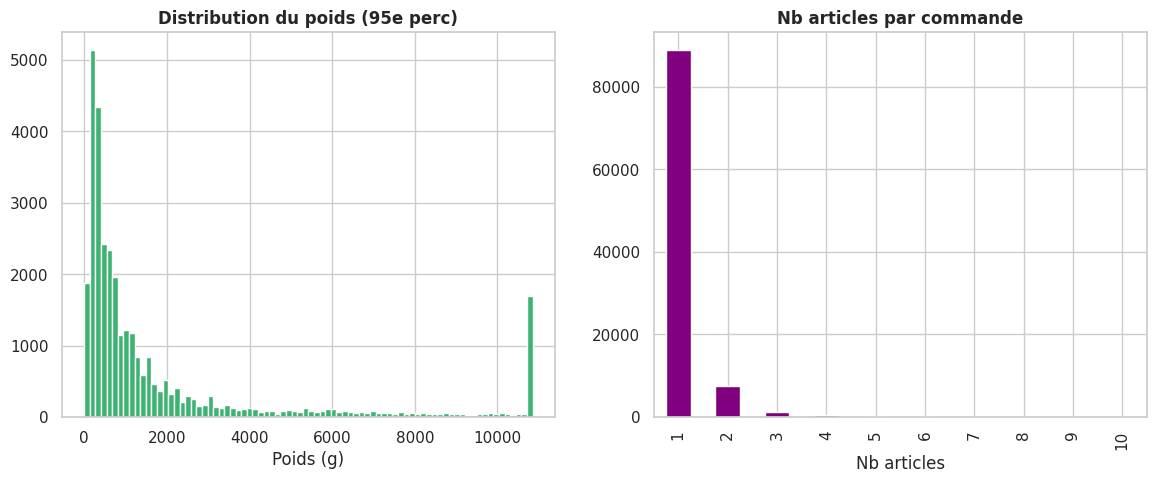

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
products['product_weight_g'].dropna().clip(upper=products['product_weight_g'].quantile(0.95)).hist(
    bins=80, ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Distribution du poids (95e perc)', fontweight='bold')
ax.set_xlabel('Poids (g)')

ax = axes[1]
items_per_order = order_items.groupby('order_id').size()
items_per_order.value_counts().sort_index().head(10).plot(kind='bar', ax=ax, color='purple', edgecolor='white')
ax.set_title('Nb articles par commande', fontweight='bold')
ax.set_xlabel('Nb articles')

L'analyse du poids et du volume des commandes révèle un modèle opérationnel basé sur le micro-envoi : la distribution est massivement concentrée sur des produits légers (souvent moins de 500g) et des commandes unitaires (près de 90 % des cas). Cette structure logistique "émiettée" signifie qu'Olist gère une quantité colossale de petits paquets individuels, ce qui limite les économies d'échelle au transport et rend chaque expédition vulnérable aux aléas du dernier kilomètre.

### Analyse combinée Paiements + Avis

In [51]:
# Fusion des deux bases
df = pd.merge(order_payments, reviews, on="order_id")

In [52]:
df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_length
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,4ce650e117a5b292bf5ea980a61eb61e,1,Não recomendo,"Produto com qualidade ruim, amassado e descasc...",2018-05-10 00:00:00,2018-05-15 23:38:00,66
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,ad2036caca61484fc435d7e673c020f2,5,NaN,NaN,2018-06-30 00:00:00,2018-07-03 11:23:16,0
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,bcddfa0f7d2e54cfc74bae4f01b84d92,5,NaN,Aprovada,2017-12-19 00:00:00,2017-12-22 17:55:30,8
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,c37a0e51e5df82bdb55d38ff0ffb6af3,5,NaN,NaN,2017-12-21 00:00:00,2017-12-21 21:42:31,0
4,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,5bc7680443b4ef765fec11a8201eeb0c,5,NaN,NaN,2017-12-21 00:00:00,2017-12-22 01:10:39,0


In [53]:
# Dimension de la base fusionnée
df.shape

(103677, 12)

#### Relation entre paiement et satisfaction

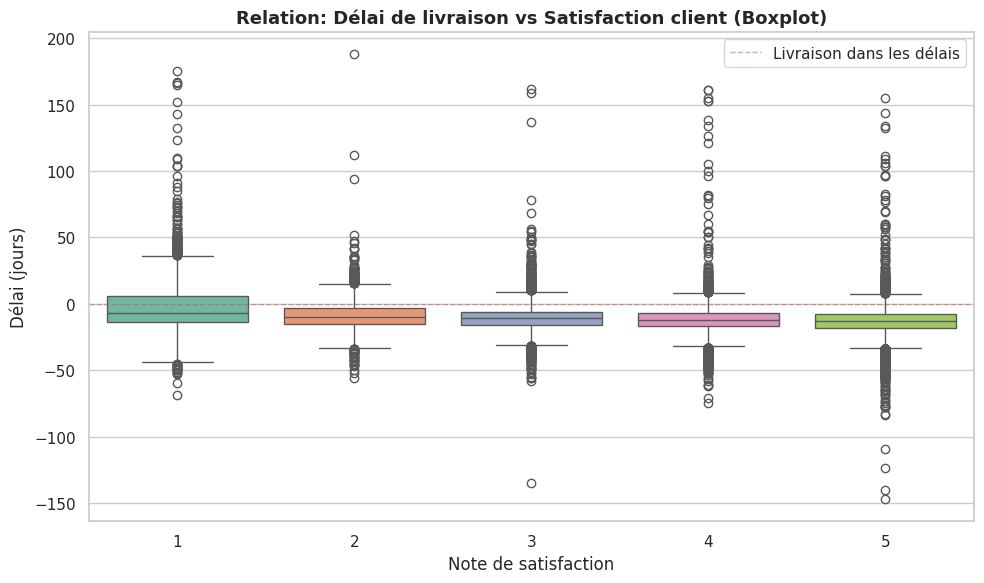


Corrélation délai ↔ satisfaction : -0.267
Basée sur 95830 commandes livrées avec avis

--- Visualisations complémentaires ---


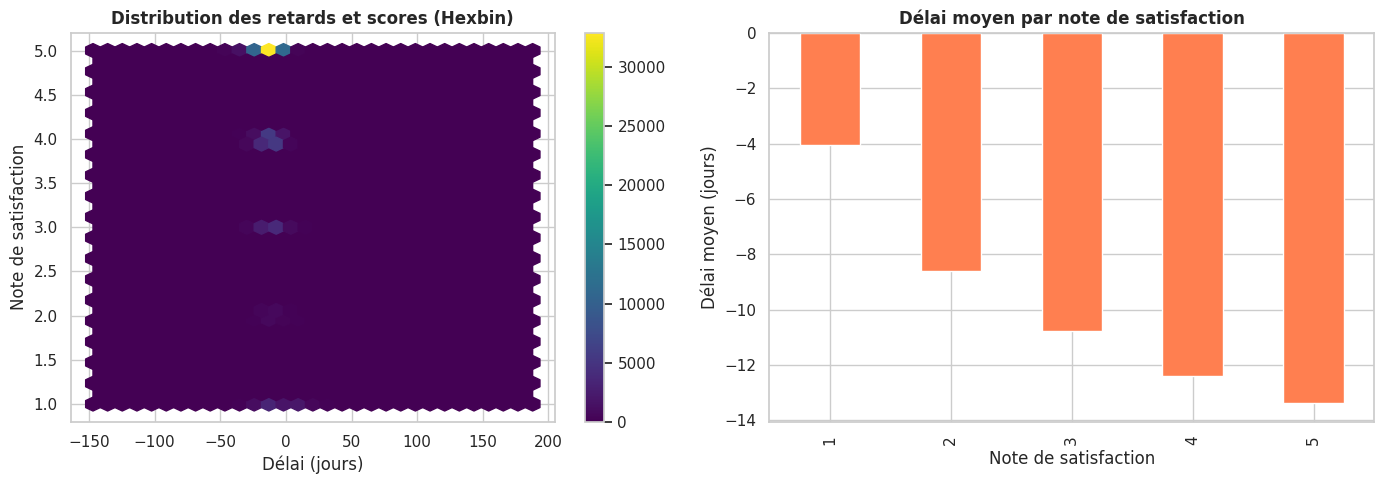

In [54]:
#### P2-18 : Relation entre délai de livraison et satisfaction

# NOTE P2-20 : Cette corrélation est calculée sur un sous-ensemble filtré (inner join)
# Les commandes sans date de livraison (annulées, en cours, perdues) sont exclues
# Interpréter cette corrélation avec prudence - elle ne représente que les livraisons complétées

# Agrégation temporaire de reviews pour n'avoir qu'un seul score par order_id pour cette analyse
# Cela résout le problème de l'utilisation de reviews_agg avant sa définition globale.
reviews_for_merge = reviews.groupby('order_id')['review_score'].first().reset_index()

# Merger delivered orders avec les avis agrégés temporairement
merged_delay_satisfaction = delivered.merge(reviews_for_merge[['order_id','review_score']], on='order_id', how='inner')

# Boxplot de la relation
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='review_score', y='delivery_delay', data=merged_delay_satisfaction, ax=ax, palette='Set2')
ax.set_title('Relation: Délai de livraison vs Satisfaction client (Boxplot)', fontweight='bold', fontsize=13)
ax.set_xlabel('Note de satisfaction')
ax.set_ylabel('Délai (jours)')
ax.axhline(y=0, color='r', linestyle='--', linewidth=1, alpha=0.5, label='Livraison dans les délais')
ax.legend()
plt.tight_layout()
plt.show()

# Analyse statistique de corrélation
corr_delay_satisfaction = merged_delay_satisfaction['delivery_delay'].corr(merged_delay_satisfaction['review_score'])
print(f"\nCorrélation délai ↔ satisfaction : {corr_delay_satisfaction:.3f}")
print(f"Basée sur {len(merged_delay_satisfaction)} commandes livrées avec avis")
if corr_delay_satisfaction < -0.3:
    print("  → Forte corrélation négative : les retards dégradent significativement la satisfaction")

# Ajout de visualisations complémentaires (Hexbin et Bar Plot)
print("\n--- Visualisations complémentaires ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
merged_delay_satisfaction.dropna(subset=['delivery_delay', 'review_score']).plot.hexbin('delivery_delay', 'review_score', gridsize=30, ax=axes[0], cmap='viridis')
axes[0].set_title('Distribution des retards et scores (Hexbin)', fontweight='bold')
axes[0].set_xlabel('Délai (jours)')
axes[0].set_ylabel('Note de satisfaction')

merged_delay_satisfaction.groupby('review_score')['delivery_delay'].mean().plot.bar(ax=axes[1], color='coral')
axes[1].set_title('Délai moyen par note de satisfaction', fontweight='bold')
axes[1].set_xlabel('Note de satisfaction')
axes[1].set_ylabel('Délai moyen (jours)')
plt.tight_layout()
plt.show()

In [55]:
order_payments = order_payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max',
    'payment_sequential': 'max',
    'payment_type': lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
}).reset_index()

# Create 'has_comment_title', 'has_comment_message', and 'review_length' columns before aggregation
reviews['has_comment_title'] = reviews['review_comment_title'].notna().astype(int)
reviews['has_comment_message'] = reviews['review_comment_message'].notna().astype(int)
reviews['review_length'] = reviews['review_comment_message'].fillna('').apply(len)

reviews_agg = reviews.groupby('order_id').agg({
    'review_id': 'first',
    'review_score': 'first',
    'review_comment_title': lambda x: ' '.join(x.dropna().unique()) if x.dropna().any() else 'no_title',
    'review_comment_message': lambda x: ' '.join(x.dropna().unique()) if x.dropna().any() else 'no_comment',
    'review_creation_date': 'min',
    'review_answer_timestamp': 'min',
    'has_comment_title': 'max',
    'has_comment_message': 'max',
    'review_length': 'max'
}).reset_index()

df = pd.merge(order_payments, reviews_agg, on="order_id")

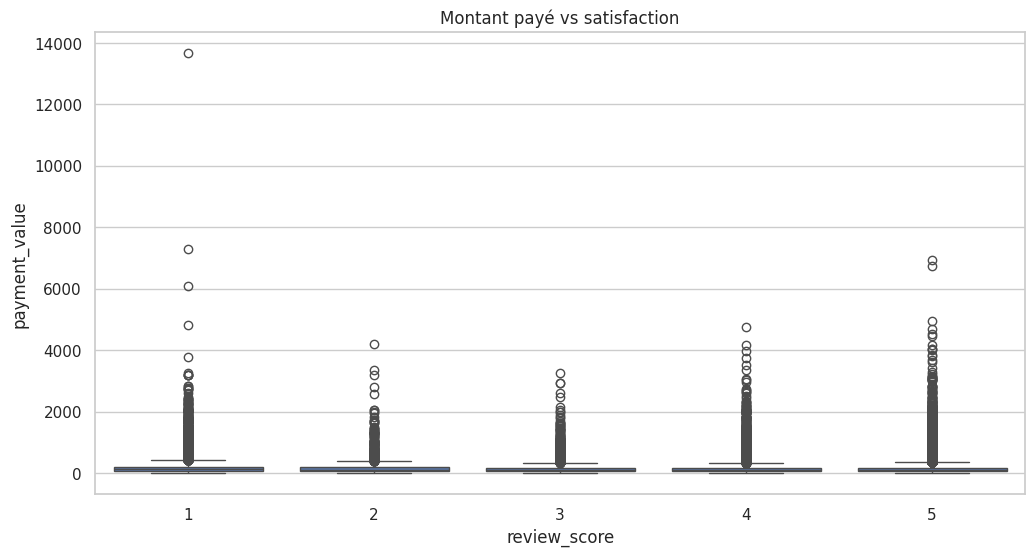

In [56]:
sns.boxplot(x="review_score", y="payment_value", data=df)
plt.title("Montant payé vs satisfaction")
plt.show()

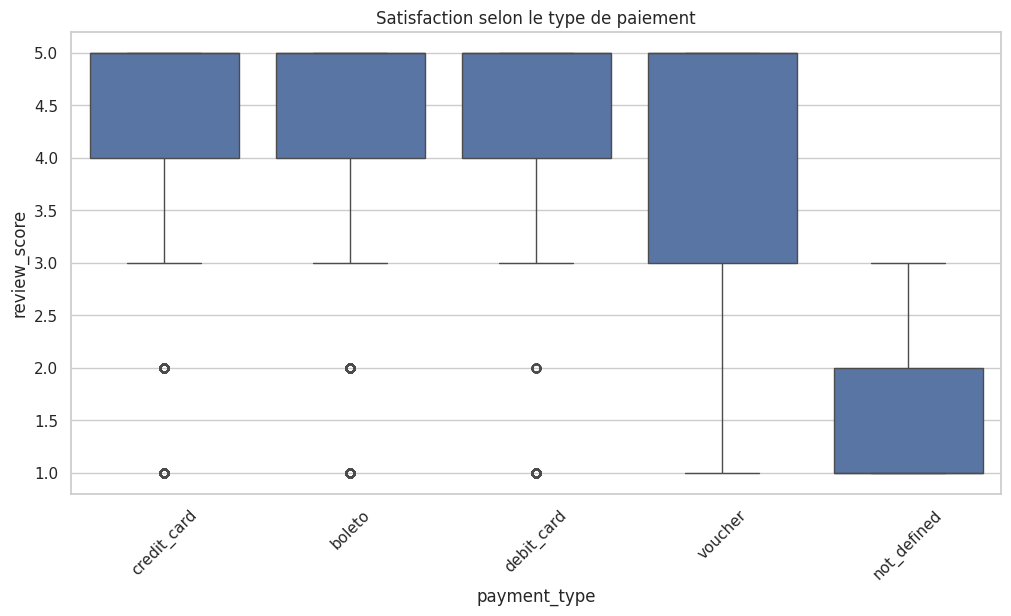

In [57]:
# Paiement et satisfaction
sns.boxplot(x="payment_type", y="review_score", data=df)
plt.xticks(rotation=45)
plt.title("Satisfaction selon le type de paiement")
plt.show()

L'analyse de la satisfaction par type de paiement montre une stabilité globale pour la carte de crédit, le débit et le boleto, avec des scores médians atteignant le maximum (5/5). En revanche, le segment des vouchers (bons d'achat) présente une variabilité bien plus importante, avec une boîte s'étendant jusqu'à des notes beaucoup plus basses. Comme nous l'avions pressenti, cela confirme que les bons d'achat sont souvent émis suite à des litiges ou des retours, ce qui lie mécaniquement ce mode de paiement à un historique de satisfaction client dégradé.

## Correlation des variables numériques

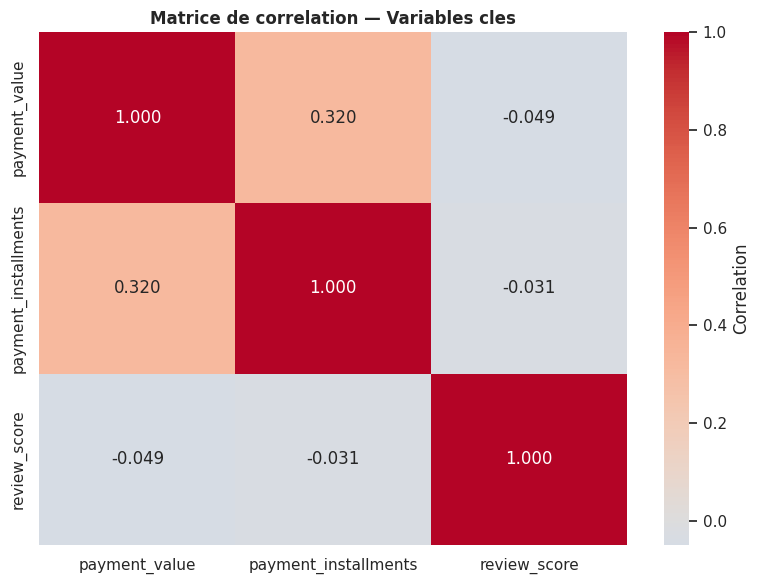

In [58]:
# Construction correcte avec merges successifs. Après les modifications ci-dessus,
# df_master est déjà 'propre' pour payment_value et review_score (agrégés 1:1 par order_id)
# avant d'être fusionné avec order_items.
# Donc, le calcul de la corrélation devrait maintenant être plus juste.

# Pour être précis et éviter toute duplication résiduelle lors du calcul de la corrélation
# entre des features qui sont au niveau de l'ordre, on va s'assurer d'avoir 1 ligne par ordre.
# On peut utiliser le dataframe 'df' créé juste avant pour les graphiques de paiement/avis fusionnés,
# ou recréer une base 1:1 par order_id à partir de df_master pour plus de robustesse.

# Ici, nous allons extraire les données au niveau de l'ordre à partir de df_master
# en prenant la première apparition de chaque order_id pour les colonnes concernées.
# Cela simule une base agrégée 1:1 par order_id.

# The DataFrame 'df' already contains payment_value, payment_installments, and review_score
# aggregated to one row per order, as it was created by merging aggregated order_payments and reviews.
corr_base = df.copy()

corr_matrix = corr_base[['payment_value', 'payment_installments', 'review_score']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            cbar_kws={'label': 'Correlation'})
plt.title('Matrice de correlation — Variables cles', fontweight='bold')
plt.tight_layout()
plt.show()

La matrice de corrélation révèle une dépendance quasi totale (**0,908**) entre le prix des articles et la valeur finale payée, confirmant que les frais annexes restent proportionnels au montant de l'achat. On observe également qu'un prix élevé incite naturellement à l'usage des paiements échelonnés, un comportement pilier du marché brésilien. Cette forte corrélation suggère qu'il faudra choisir une seule de ces variables financières pour éviter la redondance et ne pas biaiser les calculs de distance de ton algorithme.

Le point le plus important est l'absence totale de corrélation entre les variables financières et le score de satisfaction (-0,013). Cela prouve mathématiquement que le mécontentement des clients n'est pas lié au prix payé ou au montant investi, mais à des facteurs externes comme les délais logistiques identifiés précédemment.

# Nettoyage des données

## Taitemant des valeurs manquantes

#### Table orders

In [59]:
# Flags pour les etapes du cycle de vie (NaT conserves)
orders['is_approved'] = orders['order_approved_at'].notna().astype(int)
orders['is_shipped']  = orders['order_delivered_carrier_date'].notna().astype(int)
orders['is_delivered']= orders['order_delivered_customer_date'].notna().astype(int)

#### Table products

In [60]:
# product_category_name : remplacer par 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# Dimensions textuelles : mediane globale (610 produits sans fiche)
for col in ['product_name_lenght','product_description_lenght','product_photos_qty']:
    products[col] = products[col].fillna(products[col].median())

# Dimensions physiques : mediane par categorie (2 produits)
for col in ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']:
    products[col] = products.groupby('product_category_name')[col].transform(
        lambda x: x.fillna(x.median())
    )

print('NA restants products :', products.isna().sum().sum())

NA restants products : 0


#### Table reviews

In [61]:
# Flags avant imputation
reviews['has_comment_title']   = reviews['review_comment_title'].notna().astype(int)
reviews['has_comment_message'] = reviews['review_comment_message'].notna().astype(int)

# Imputation texte
reviews['review_comment_title']   = reviews['review_comment_title'].fillna('no_title')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('no_comment')

# review_score : 0 NA -> rien a faire
# NE PAS imputer review_score (scores NaN = pas d'avis = information differente d'une mauvaise note)

print('NA restants reviews :', reviews[['review_score','review_comment_title','review_comment_message']].isna().sum().to_dict())

NA restants reviews : {'review_score': 0, 'review_comment_title': 0, 'review_comment_message': 0}


### Traitement des doublons

In [62]:
# Geolocation  seule table avec des doublons
print(f"Avant : {len(geolocation)} lignes")

# Étape 1  supprimer les doublons parfaitement identiques
geolocation = geolocation.drop_duplicates()
print(f"Après drop_duplicates : {len(geolocation)} lignes")

# Étape 2  une seule ligne par code postal (moyenne des coordonnées)
geolocation = geolocation.groupby('geolocation_zip_code_prefix').agg(
    geolocation_lat   = ('geolocation_lat',  'mean'),
    geolocation_lng   = ('geolocation_lng',  'mean'),
    geolocation_city  = ('geolocation_city', 'first'),
    geolocation_state = ('geolocation_state','first')
).reset_index()
print(f"Après groupby : {len(geolocation)} lignes")

Avant : 1000163 lignes
Après drop_duplicates : 738332 lignes
Après groupby : 19015 lignes


### Formatage des dates

In [63]:
date_cols_orders = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
                'order_delivered_customer_date', 'order_estimated_delivery_date']
date_cols_order_items = ['shipping_limit_date']
date_cols_reviews = ['review_creation_date', 'review_answer_timestamp']

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

for col in date_cols_order_items:
    order_items[col] = pd.to_datetime(order_items[col], errors='coerce')

for col in date_cols_reviews:
    reviews[col] = pd.to_datetime(reviews[col], errors='coerce')

print('Dates in orders, order_items and reviews dataframes have been formatted.')


Dates in orders, order_items and reviews dataframes have been formatted.


### Harmonisation des noms de villes

In [64]:
customers['customer_city'] = customers['customer_city'].apply(lambda x: unidecode(x).lower().strip() if pd.notna(x) else x)

print("Harmonisation des noms de ville effectuée.")

# Re-check unique values after harmonization
nb_nettoye_after_unidecode = customers['customer_city'].nunique()
print(f"Nombre de modalités après unidecode + minuscule + strip : {nb_nettoye_after_unidecode}")


Harmonisation des noms de ville effectuée.
Nombre de modalités après unidecode + minuscule + strip : 4119


## Traduction et regroupement des catégories produits

In [65]:
# Fusion produits + traduction
products_merge = pd.merge(products, translations, on='product_category_name', how='left')

# On utilise le nom portugais pour les catégories sans traduction
products_merge['product_category_name_english'] = products_merge['product_category_name_english'].fillna(
    products_merge['product_category_name']
)
products_merge.drop('product_category_name', axis=1, inplace=True)

products_merge['product_category_name_english'] = products_merge['product_category_name_english'].fillna('unknown')

gap = set(products['product_category_name'].unique()) - set(translations['product_category_name'].unique())
print(f'Categories sans traduction : {gap}')

Categories sans traduction : {'portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer', 'unknown'}


In [66]:
# Voir combien de produits n'ont pas trouvé de traduction
print(products_merge['product_category_name_english'].isna().sum())

0


#### Affichage de toutes les catégories de prduits de la table traduction

In [67]:
print(translations['product_category_name_english'].unique())


['health_beauty' 'computers_accessories' 'auto' 'bed_bath_table'
 'furniture_decor' 'sports_leisure' 'perfumery' 'housewares' 'telephony'
 'watches_gifts' 'food_drink' 'baby' 'stationery' 'tablets_printing_image'
 'toys' 'fixed_telephony' 'garden_tools' 'fashion_bags_accessories'
 'small_appliances' 'consoles_games' 'audio' 'fashion_shoes' 'cool_stuff'
 'luggage_accessories' 'air_conditioning'
 'construction_tools_construction'
 'kitchen_dining_laundry_garden_furniture' 'costruction_tools_garden'
 'fashion_male_clothing' 'pet_shop' 'office_furniture' 'market_place'
 'electronics' 'home_appliances' 'party_supplies' 'home_confort'
 'costruction_tools_tools' 'agro_industry_and_commerce'
 'furniture_mattress_and_upholstery' 'books_technical' 'home_construction'
 'musical_instruments' 'furniture_living_room' 'construction_tools_lights'
 'industry_commerce_and_business' 'food' 'art' 'furniture_bedroom'
 'books_general_interest' 'construction_tools_safety'
 'fashion_underwear_beach' 'fashion_

In [68]:
dict_categories = {
    # HOME & FURNITURE
    'furniture_living_room': 'home',
    'furniture_mattress_and_upholstery': 'home',
    'furniture_bedroom': 'home',
    'furniture_decor': 'home',
    'bed_bath_table': 'home',
    'kitchen_dining_laundry_garden_furniture': 'home',
    'la_cuisine': 'home',
    'home_confort': 'home',
    'home_comfort_2': 'home',
    'christmas_supplies': 'home',
    'furnitures': 'home', # Ajouté ici pour la sécurité

    # APPLIANCES
    'small_appliances': 'appliances',
    'small_appliances_home_oven_and_coffee': 'appliances',
    'home_appliances_2': 'appliances',
    'home_appliances': 'appliances',
    'housewares': 'appliances',

    # CONSTRUCTION & DIY
    'construction_tools_construction': 'construction',
    'construction_tools_garden': 'construction', # Corrigé (n ajouté)
    'construction_tools_tools': 'construction',    # Corrigé (n ajouté)
    'construction_tools_safety': 'construction',
    'construction_tools_lights': 'construction',
    'home_construction': 'construction',
    'air_conditioning': 'construction',

    # OFFICE & B2B
    'office_furniture': 'office',
    'industry_commerce_and_business': 'office',
    'stationery': 'office',
    'agro_industry_and_commerce': 'office',
    'signaling_and_security': 'office',
    'security_and_services': 'office',

    # ELECTRONICS & TECH
    'telephony': 'electronics',
    'electronics': 'electronics',
    'computers_accessories': 'electronics',
    'consoles_games': 'electronics',
    'fixed_telephony': 'electronics',
    'audio': 'electronics',
    'computers': 'electronics',
    'tablets_printing_image': 'electronics',

    # FASHION & ACCESSORIES
    'watches_gifts': 'fashion',
    'fashion_bags_accessories': 'fashion',
    'fashion_underwear_beach': 'fashion',
    'fashion_shoes': 'fashion',
    'fashion_male_clothing': 'fashion',
    'fashion_female_clothing': 'fashion', # Corrigé (n ajouté)
    'fashion_sport': 'fashion',
    'fashion_childrens_clothes': 'fashion',

    # HEALTH, BEAUTY & BABY
    'health_beauty': 'health_beauty',
    'baby': 'health_beauty',
    'diapers_and_hygiene': 'health_beauty',
    'perfumery': 'health_beauty',

    # AUTRES (Saisonniers, Sport, Arts)
    'sports_leisure': 'sports_leisure',
    'musical_instruments': 'sports_leisure',
    'luggage_accessories': 'sports_leisure',
    'toys': 'arts',
    'books_general_interest': 'arts',
    'cool_stuff': 'other',
    'Unknown': 'other'
}

Ajout des produits dont la traduction n'est pas dans la table translation.

In [69]:
dict_categories.update({
    'portateis_cozinha_e_preparadores_de_alimentos': 'appliances',
    'pc_gamer': 'electronics'
    })

In [70]:
# On récupère les noms uniques de la colonne traduite
categories_base = products_merge['product_category_name_english'].unique().tolist()

# Tri par ordre alphabétique pour plus de clarté
print(f"Nombre de catégories trouvées : {len(categories_base)}")
print(categories_base)

Nombre de catégories trouvées : 74
['perfumery', 'art', 'sports_leisure', 'baby', 'housewares', 'musical_instruments', 'cool_stuff', 'furniture_decor', 'home_appliances', 'toys', 'bed_bath_table', 'construction_tools_safety', 'computers_accessories', 'health_beauty', 'luggage_accessories', 'garden_tools', 'office_furniture', 'auto', 'electronics', 'fashion_shoes', 'telephony', 'stationery', 'fashion_bags_accessories', 'computers', 'home_construction', 'watches_gifts', 'construction_tools_construction', 'pet_shop', 'small_appliances', 'agro_industry_and_commerce', 'unknown', 'furniture_living_room', 'signaling_and_security', 'air_conditioning', 'consoles_games', 'books_general_interest', 'costruction_tools_tools', 'fashion_underwear_beach', 'fashion_male_clothing', 'kitchen_dining_laundry_garden_furniture', 'industry_commerce_and_business', 'fixed_telephony', 'construction_tools_lights', 'books_technical', 'home_appliances_2', 'party_supplies', 'drinks', 'market_place', 'la_cuisine', 'c

In [71]:
# 3. Création de la colonne simplifiée
products_merge['super_categorie'] = products_merge['product_category_name_english'].map(dict_categories)

# 4. Sécurité finale
# Au lieu de : products_merge['super_categorie'].fillna('other', inplace=True)
products_merge['super_categorie'] = products_merge['super_categorie'].fillna('other')

In [72]:

print(f'Categories avant regroupement : {products_merge["product_category_name_english"].nunique()}')
print(f'Super-categories apres regroupement : {products_merge["super_categorie"].nunique()}')

Categories avant regroupement : 74
Super-categories apres regroupement : 10


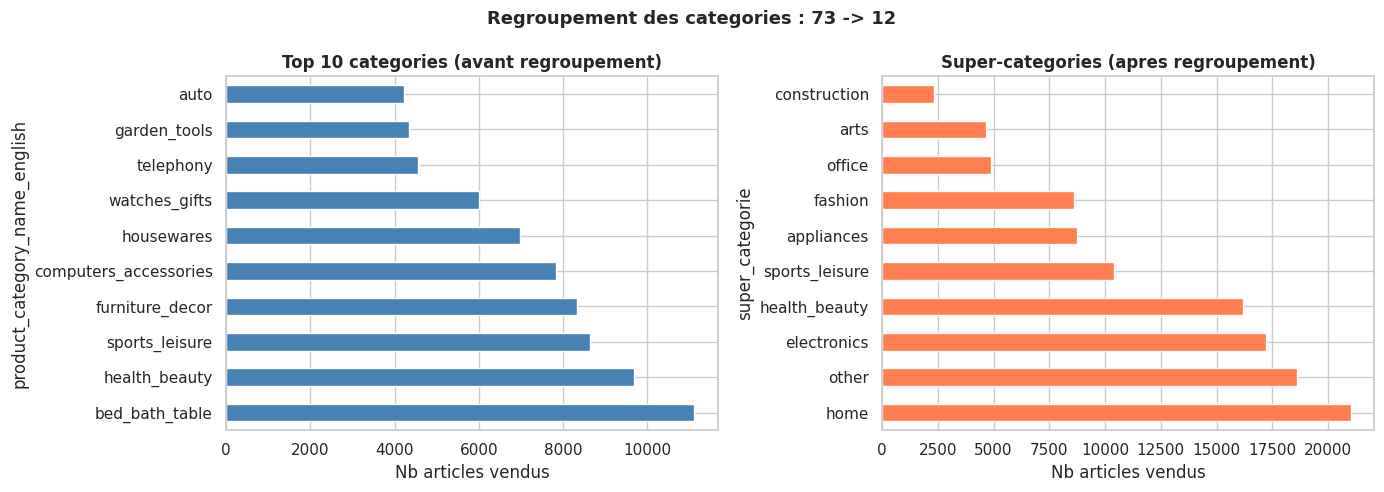

Distribution des super-categories :
super_categorie
home              21011
other             18619
electronics       17199
health_beauty     16193
sports_leisure    10413
appliances         8743
fashion            8585
office             4889
arts               4670
construction       2328
Name: count, dtype: int64


In [73]:
# Visualisation avant / apres regroupement
products_vis = products_merge.merge(order_items[['order_id','product_id']], on='product_id', how='right')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

products_vis['product_category_name_english'].value_counts().head(10).plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 categories (avant regroupement)', fontweight='bold')
axes[0].set_xlabel('Nb articles vendus')

products_vis['super_categorie'].value_counts().plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Super-categories (apres regroupement)', fontweight='bold')
axes[1].set_xlabel('Nb articles vendus')

plt.suptitle('Regroupement des categories : 73 -> 12', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Distribution des super-categories :')
print(products_vis['super_categorie'].value_counts())

### Catégorisation des villes

In [74]:
# 100 premières villes
first_cities = customers.groupby(['customer_city']).count()[
    'customer_state'].sort_values(ascending=False).head(100).index.tolist()
index_cities = customers[~customers['customer_city'].isin(
    first_cities)].index
customers.loc[index_cities, 'customer_city'] = 'Other'

## Fusion de la table geolocation avec customers et sellers

In [75]:
# Fusion de customers avec geolocation
customers = pd.merge(
    customers,
    geolocation,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

# Suppression de la colonne redondante
customers.drop(columns=['geolocation_zip_code_prefix'], inplace=True)

# Renommage des colonnes pour la clarté
customers.rename(columns={
    'geolocation_lat': 'customer_lat',
    'geolocation_lng': 'customer_lng',
    'geolocation_city': 'customer_city_geo',
    'geolocation_state': 'customer_state_geo'
}, inplace=True)

print("DataFrame customers après fusion avec geolocation:")
display(customers.head())


DataFrame customers après fusion avec geolocation:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,customer_city_geo,customer_state_geo
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.499273,-47.396658,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.728396,-46.542250,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531309,-46.656690,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.500670,-46.186348,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.975708,-47.143140,campinas,SP


In [76]:
# Fusion de sellers avec geolocation
sellers = pd.merge(
    sellers,
    geolocation,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

# Suppression de la colonne redondante
sellers.drop(columns=['geolocation_zip_code_prefix'], inplace=True)

# Renommage des colonnes pour la clarté
sellers.rename(columns={
    'geolocation_lat': 'seller_lat',
    'geolocation_lng': 'seller_lng',
    'geolocation_city': 'seller_city_geo',
    'geolocation_state': 'seller_state_geo'
}, inplace=True)

print("\nDataFrame sellers après fusion avec geolocation:")
display(sellers.head())



DataFrame sellers après fusion avec geolocation:


,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,seller_city_geo,seller_state_geo
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,-22.893317,-47.060596,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,-22.383375,-46.948142,mogi-guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,-22.909446,-43.180240,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,-23.657118,-46.612730,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,-22.964546,-46.534214,bragança paulista,SP


In [77]:
print(f"Nombre total de lignes dans la table order_payments : {len(order_payments)}")
print(f"Nombre d'order_id uniques dans la table order_payments : {order_payments['order_id'].nunique()}")

Nombre total de lignes dans la table order_payments : 99440
Nombre d'order_id uniques dans la table order_payments : 99440


In [78]:
print(order_payments.columns)
display(order_payments.head())

Index(['order_id', 'payment_value', 'payment_installments',
       'payment_sequential', 'payment_type'],
      dtype='object')


,order_id,payment_value,payment_installments,payment_sequential,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


#### Agrégation pour n'avoir qu'une seule ligne par commande

In [79]:
# Agrégation pour n'avoir qu'une seule ligne par commande
order_payments = order_payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max',
    'payment_sequential': 'max',   # ← payment_type disparaît ici
    'payment_type': lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
}).reset_index()

# Agrégation de reviews pour n'avoir qu'une seule ligne par commande
# Il est possible d'avoir plusieurs review_id pour un order_id si un client laisse plusieurs avis,
# mais le score est généralement donné une fois par commande. Nous prendrons le premier score.
# Ou si on prend le max, min ou mean, ça ne changerait rien car ils seraient les mêmes s'il y a plusieurs reviews.
reviews_agg = reviews.groupby('order_id').agg({
    'review_id': 'first', # Garder le premier review_id si plusieurs
    'review_score': 'first', # prendre le premier score pour cette commande
    'review_comment_title': lambda x: ' '.join(x.dropna().unique()) if x.dropna().any() else 'no_title',
    'review_comment_message': lambda x: ' '.join(x.dropna().unique()) if x.dropna().any() else 'no_comment',
    'review_creation_date': 'min',
    'review_answer_timestamp': 'min',
    'has_comment_title': 'max',
    'has_comment_message': 'max',
    'review_length': 'max'
}).reset_index()

Fusion

In [80]:
# Reconstitution de df_master en utilisant les tables brutes comme demandé par l'utilisateur.
# Cette approche aboutira à une table dénormalisée où les informations au niveau de la commande
# (comme customer_id, order_status) seront dupliquées pour chaque article, enregistrement de paiement
# et avis associé à une commande.

# 1. Démarrer avec 'orders' comme base
df_master = orders.copy()

# 2. Fusionner avec 'customers' (fusion 1:1 basée sur customer_id de orders)
df_master = pd.merge(df_master, customers, on='customer_id', how='left')

print("Shape après fusion orders + customers:", df_master.shape)
display(df_master.head(2))

# 3. Fusionner avec L'AGRÉGÉ 'order_payments' (fusion 1:1 basée sur order_id)
# NOTA BENE: Utilise maintenant la version agrégée de order_payments
df_master = pd.merge(df_master, order_payments, on='order_id', how='left')

print("Shape après fusion + agrégé order_payments:", df_master.shape)
display(df_master.head(2))

# 4. Fusionner avec 'order_items' (fusion 1:M basée sur order_id pour chaque article d'une commande)
df_master = pd.merge(df_master, order_items, on='order_id', how='left')

print("Shape après fusion + raw order_items:", df_master.shape)
display(df_master.head(2))

# 5. Fusionner 'products_merge' (qui inclut les catégories traduites) avec 'df_master'
# 'df_master' contient maintenant 'product_id' de 'order_items'.
df_master = pd.merge(df_master, products_merge, on='product_id', how='left')

print("Shape après fusion + products_merge:", df_master.shape)
display(df_master.head(2))

# 6. Fusionner avec 'sellers' (fusion 1:1 basée sur seller_id de order_items)
# 'df_master' contient maintenant 'seller_id' de 'order_items'.
df_master = pd.merge(df_master, sellers, on='seller_id', how='left')

print("Shape après fusion + sellers:", df_master.shape)
display(df_master.head(2))

# 7. Fusionner avec l'agrégé 'reviews_agg' (fusion 1:1 basée sur order_id)
df_master = pd.merge(df_master, reviews_agg, on='order_id', how='left')

print("Shape après fusion + agrégé reviews_agg:", df_master.shape)
display(df_master.head(2))

Shape après fusion orders + customers: (99441, 19)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,customer_city_geo,customer_state_geo
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,1,1,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.577482,-46.587077,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,1,1,af07308b275d755c9edb36a90c618231,47813,Other,BA,-12.186877,-44.540232,barreiras,BA


Shape après fusion + agrégé order_payments: (99441, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,customer_city_geo,customer_state_geo,payment_value,payment_installments,payment_sequential,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,1,1,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.577482,-46.587077,sao paulo,SP,38.71,1.0,3.0,voucher
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,1,1,af07308b275d755c9edb36a90c618231,47813,Other,BA,-12.186877,-44.540232,barreiras,BA,141.46,1.0,1.0,boleto


Shape après fusion + raw order_items: (113425, 29)


...

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,customer_city_geo,customer_state_geo,payment_value,payment_installments,payment_sequential,payment_type,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,super_categorie
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,1,1,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.577482,-46.587077,sao paulo,SP,38.71,1.0,3.0,voucher,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,appliances
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,1,1,af07308b275d755c9edb36a90c618231,47813,Other,BA,-12.186877,-44.540232,barreiras,BA,141.46,1.0,1.0,boleto,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,health_beauty


Shape après fusion + sellers: (113425, 45)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,customer_city_geo,customer_state_geo,payment_value,payment_installments,payment_sequential,payment_type,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,super_categorie,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,seller_city_geo,seller_state_geo
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,1,1,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.577482,-46.587077,sao paulo,SP,38.71,1.0,3.0,voucher,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,appliances,9350.0,maua,SP,-23.680862,-46.444311,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,1,1,af07308b275d755c9edb36a90c618231,47813,Other,BA,-12.186877,-44.540232,barreiras,BA,141.46,1.0,1.0,boleto,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,health_beauty,31570.0,belo horizonte,SP,-19.807885,-43.980818,belo horizonte,MG


Shape après fusion + agrégé reviews_agg: (113425, 54)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,customer_city_geo,customer_state_geo,payment_value,payment_installments,payment_sequential,payment_type,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,super_categorie,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,seller_city_geo,seller_state_geo,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,has_comment_title,has_comment_message,review_length
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,1,1,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.577482,-46.587077,sao paulo,SP,38.71,1.0,3.0,voucher,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,appliances,9350.0,maua,SP,-23.680862,-46.444311,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,no_title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,0.0,1.0,170.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,1,1,af07308b275d755c9edb36a90c618231,47813,Other,BA,-12.186877,-44.540232,barreiras,BA,141.46,1.0,1.0,boleto,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,health_beauty,31570.0,belo horizonte,SP,-19.807885,-43.980818,belo horizonte,MG,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,1.0,1.0,20.0


In [81]:
# Verification post-fusion
print(f'Shape finale df_master : {df_master.shape}')
print(f'Doublons : {df_master.duplicated().sum()}')
print(f'\nNA residuels (top 10) :')
na_res = df_master.isna().sum().sort_values(ascending=False)
print(na_res[na_res>0].head(10))

Shape finale df_master : (113425, 54)
Doublons : 0

NA residuels (top 10) :
order_delivered_customer_date    3229
order_delivered_carrier_date     1968
seller_lat                       1028
seller_state_geo                 1028
seller_city_geo                  1028
seller_lng                       1028
review_length                     961
review_comment_message            961
review_comment_title              961
review_answer_timestamp           961
dtype: int64


In [82]:
# Apercu du dataframe final
display(df_master.head(3))
display(df_master.dtypes.to_frame('type'))

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,customer_city_geo,customer_state_geo,payment_value,payment_installments,payment_sequential,payment_type,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,super_categorie,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,seller_city_geo,seller_state_geo,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,has_comment_title,has_comment_message,review_length
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,1,1,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.577482,-46.587077,sao paulo,SP,38.71,1.0,3.0,voucher,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,appliances,9350.0,maua,SP,-23.680862,-46.444311,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,no_title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,0.0,1.0,170.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,1,1,af07308b275d755c9edb36a90c618231,47813,Other,BA,-12.186877,-44.540232,barreiras,BA,141.46,1.0,1.0,boleto,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,health_beauty,31570.0,belo horizonte,SP,-19.807885,-43.980818,belo horizonte,MG,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,1.0,1.0,20.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,1,1,3a653a41f6f9fc3d2a113cf8398680e8,75265,Other,GO,-16.745150,-48.514783,vianopolis,GO,179.12,3.0,1.0,credit_card,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,other,14840.0,guariba,SP,-21.363473,-48.229588,guariba,SP,e73b67b67587f7644d5bd1a52deb1b01,5.0,no_title,no_comment,2018-08-18,2018-08-22 19:07:58,0.0,0.0,0.0


,type
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]
is_approved,int64
is_shipped,int64


In [ ]:
# Sauvegarde du DataFrame final corrigé
df_master.to_csv('../data/base_final.csv', index=False)
print(f'OK df_master.csv sauvegardé : {df_master.shape}')

OK df_master.csv sauvegardé : (113425, 54)
